## Bayesian XG Model 
### by Adam Sequeira 
- [reference paper here](https://arxiv.org/abs/2311.13707)

#### Problem Statement 
In football there is a varying scale of richness of tagging data: 
 - Providers that only provide generic spatial coordinates (x,y) for shots
 - Providers that provide the same spatial coordinates alongside contextual features like (shot_body_part, shot_technique)... etc..
 - Providers like statsbomb that provide shots, contextual features and 360 freeze frame data, which contains off ball player positions

Less rich datasets, can generate fewer relevant features, results is less accurate xG values as per calibration and logloss. This was demonstrated in my GLM xg model project located [here](https://github.com/addybrown/DataScienceProjects/tree/main/GLMXgModel), there are also a pleathora of papers on xG that demonstrate this. 

This creates a challenge when comparing xG values from different data providers. This translates to both player as well as team analysis, some players play youth football is non-affilated leagues with lower quality control on the tagging. 

Bayesian modeling provides a natural framework for addressing this problem. Rather than producing a single probability estimate, Bayesian models generate a posterior distribution over the goal probability. This distribution quantifies both the estimated probability of scoring and the uncertainty surrounding that estimate. 

This project will aim to do the following:
- Build a xG model using Bayesian Inference as outlined by the paper above. 
- Ensure less rich data sources, have more uncertainty, and the level of uncertainity scales to the number of missing features. 

In other words, more relevant features (narrower posterior), less rich features (wider posterior)

#### Why is this Relevant? 
The ability to quantify uncertainty is valuable for both practitioners and researchers. In football analytics, model outputs are often used to evaluate player/match shot quality. In recruitment, players go through different systems with different levels of richness in their data. 

A probabilistic framework also allows analysts to:

Distinguish between aleatoric uncertainty (inherent randomness in goal scoring) and epistemic uncertainty (uncertainty arising from limited information).
Compare xG estimates across datasets with different levels of feature richness.
Incorporate uncertainty directly into downstream models and decision-making processes.
Produce more robust estimates in situations with sparse data or rare events.

#### Goal 
- Generate one size fits all bayesian xg model that provides the following
    - posterior distribution of outcomes instead of standard point estimates 
    - able to factor in error for different tagging systems. 

In [484]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Data Analysis 

Majority of the data analysis feature engineering etc.. was borrowed from the GLM model shown [here](https://github.com/addybrown/DataScienceProjects/tree/main/GLMXgModel) as well as the paper above. As such, this notebook will refrain from repeating many of the same analysis steps. 

The data analysis below will utimately, 

### Bin Features
- Based on the full sample data 40,000 shots, can formulate Beta priors that somewhat match these ratios. (for latent variables --> explained below)

/var/folders/k4/1yywxhx51772qf1hj2k0zrqh0000gn/T/ipykernel_20948/2386407404.py:5: DtypeWarning: Columns (0: shot_first_time, 1: shot_follows_dribble, 2: assist_type, 3: assist_height, 4: under_pressure, 5: is_open_goal) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_data = pd.read_csv("data/bayesian_sample_data.csv")


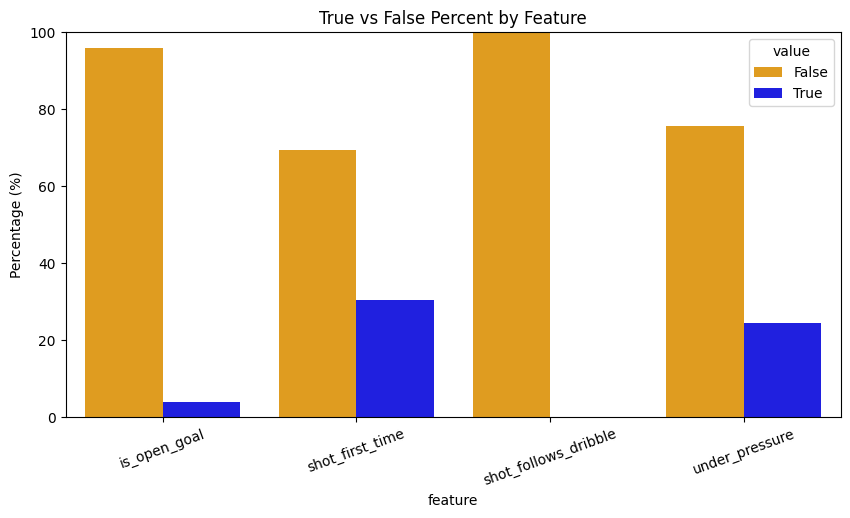

In [505]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sample_data = pd.read_csv("data/bayesian_sample_data.csv")

cat_cols = [
    "shot_first_time",
    "shot_follows_dribble",
    "under_pressure",
    "is_open_goal",
]

df = sample_data[cat_cols].copy().reset_index(drop=True)

# long format
df_long = df.melt(var_name="feature", value_name="value")

# compute percentages safely
counts = df_long.groupby(["feature", "value"]).size().reset_index(name="count")

counts["percent"] = counts["count"] / counts.groupby("feature")["count"].transform("sum") * 100

plt.figure(figsize=(10, 5))

sns.barplot(
    data=counts,
    x="feature",
    y="percent",
    hue="value",
    palette={True: "blue", False: "orange"}
)

plt.ylim(0, 100)
plt.ylabel("Percentage (%)")
plt.title("True vs False Percent by Feature")
plt.xticks(rotation=20)
plt.show()

## Model Formulation: Hierarchical Data-Quality Mixture xG Model

This model estimates the probability of a shot resulting in a goal ($y \in \{0, 1\}$) by explicitly decoupling **on-pitch tracking attributes** from **data-collection quality indicators**. When tracking data features drop out, the model dynamically inflates its epistemic uncertainty via a latent Beta-Binomial architecture.

---

### 1. Generative Architecture & Likelihood
The binary shot outcome $y_i$ for a given record $i$ is distributed according to a **Beta-Binomial** distribution with $n=1$ (effectively a marginalized Beta-Bernoulli trial):

$$y_i \sim \text{BetaBinomial}(n=1, \, \alpha_{i}, \, \beta_{i})$$

To isolate the deterministic baseline probability ($xG$) from information degradation, the parameters $\alpha_{i}$ and $\beta_{i}$ are reparameterized via the expectation location $p_{\text{baseline}, i}$ and a dynamically scaled precision concentration $\kappa_{i}$:

$$\alpha_{i} = p_{\text{baseline}, i} \times \kappa_{i}$$
$$\beta_{i} = (1 - p_{\text{baseline}, i}) \times \kappa_{i}$$

---

### 2. Information Quality & Variance Inflation Gating
The data quality parameter $\kappa_{i}$ controls the variance inflation of individual predictions. It calculates a weighted linear penalty based on a vector of binary missingness indicators $m_{f, i} \in \{0, 1\}$ across $F$ features:

$$\text{missingness}_i = 3.0 \left(m_{\text{sbp}} + m_{\text{pp}} + m_{\text{st}} + m_{\text{gk\_dist}} + m_{\text{open\_g}}\right)_i + 2.0 \left(m_{\text{shot\_dist}}\right)_i + 1.0 \sum_{c \in \text{others}} m_{c, i}$$

$$\text{quality}_i = 1.0 - \frac{\text{missingness}_i}{27.0}$$

$$\kappa_{i} = \left(\text{quality}_i \times \Omega_{\text{max}}\right) + 2.0$$

Where the ceiling concentration parameter is governed globally by an exponential hyperprior:
$$\Omega_{\text{max}} \sim \text{Exponential}(\lambda = 0.05)$$

---

### 3. The Latent Linear System ($\mu$)
The location parameter is mapped to an unconstrained continuous linear space via the logistic sigmoid link function:

$$p_{\text{baseline}, i} = \sigma(\mu_i) = \frac{1}{1 + e^{-\mu_i}}$$

The linear system $\mu_i$ integrates three feature groups (continuous tracking metrics, binary context flags, and categorical multi-class effects):

$$\begin{aligned}
\mu_i = \alpha &+ \beta_{\text{angle}} \tilde{x}_{\text{angle}, i} + \beta_{\text{dist}} \tilde{x}_{\text{dist}, i} + \beta_{\text{dist\_ang}} \tilde{x}_{\text{dist\_ang}, i} \\
&+ \beta_{\text{gk\_dist}} \tilde{x}_{\text{gk\_dist}, i} + \beta_{\text{gk\_ang}} \tilde{x}_{\text{gk\_ang}, i} + \beta_{\text{gk\_dist\_ang}} \tilde{x}_{\text{gk\_dist\_ang}, i} \\
&+ \beta_{\text{players}} \tilde{x}_{\text{players}, i} + \beta_{\text{ft}} \tilde{b}_{\text{ft}, i} + \beta_{\text{fd}} \tilde{b}_{\text{fd}, i} + \beta_{\text{press}} \tilde{b}_{\text{press}, i} + \beta_{\text{open}} \tilde{b}_{\text{open}, i} \\
&+ \gamma_{\text{pressure}, i} + \gamma_{\text{sbp}, i} + \gamma_{\text{st}, i} + \gamma_{\text{at}, i} + \gamma_{\text{ah}, i} + \gamma_{\text{pp}, i}
\end{aligned}$$

---

### 4. Continuous & Binary Latent Coupling Gates
For missing data rows ($m_{f, i} = 1$), features are softly coupled to non-centered random variables instead of static zeroes, preserving full geometric differentiability:

#### Continuous Tracking Metrics (Standard Normal Latents)
$$\tilde{x}_{f, i} = x_{f, i}(1 - m_{f, i}) + shot\_f\_mis\_lat \cdot m_{f, i} \quad \text{where} \quad shot\_f\_mis\_lat \sim \mathcal{N}(0, 1)$$

#### Binary Context Attributes (Informative Beta Domain Latents)
$$\tilde{b}_{f, i} = b_{f, i}(1 - m_{f, i}) + \theta_{f} \cdot m_{f, i}$$

$$\begin{aligned}
\theta_{\text{first\_time}} &\sim \text{Beta}(30, 70) \\
\theta_{\text{follows\_dribble}} &\sim \text{Beta}(1, 9999) \\
\theta_{\text{under\_pressure}} &\sim \text{Beta}(30, 70) \\
\theta_{\text{is\_open\_goal}} &\sim \text{Beta}(5, 95)
\end{aligned}$$

---

### 5. Categorical Embeddings & Unseen Baseline Effects
Categorical multi-class variables index directly into distributed parameter matrices when observed. If missing or unobserved, the row smoothly defaults to a global error baseline effect:

$$\gamma_{\text{field}, i} = \begin{cases} 
      \mathbf{E}_{\text{field}}[k_i] & \text{if } m_{\text{field}, i} = 0 \\
      \delta_{\text{field\_missing}} & \text{if } m_{\text{field}, i} = 1 
   \end{cases}$$

---

### 6. Coefficient & Parameter Priors
The global intercept, coefficients, and localized embedding spaces are initialized with standard weakly informative or structurally directional priors:

$$\alpha \sim \mathcal{N}(\mu = -2.2, \, \sigma = 1)$$

$$\begin{aligned}
\beta_{\text{angle}}, \beta_{\text{gk\_dist}}, \beta_{\text{gk\_ang}} &\sim \text{SkewNormal}(\mu=0, \, \sigma=5, \, \alpha=1 \text{ or } 4) \\
\beta_{\text{dist}}, \beta_{\text{gk\_dist\_ang}}, \beta_{\text{players}} &\sim \text{SkewNormal}(\mu=0, \, \sigma=5, \, \alpha=-1 \text{ or } -6) \\
\beta_{\text{first\_time}}, \beta_{\text{follows\_dribble}}, \beta_{\text{under\_pressure}} &\sim \mathcal{N}(0, \, 5) \\
\beta_{\text{is\_open\_goal}} &\sim \text{SkewNormal}(0, \, 5, \, \alpha=4)
\end{aligned}$$

$$\mathbf{E}_{\text{field}} \sim \mathcal{N}(0, \, 1) \quad \text{and} \quad \delta_{\text{field\_missing}} \sim \mathcal{N}(0, \, 1)$$

In [338]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class BayesianXg:
    """
    Bayesian expected goals model.

    Sampling options
    ----------------
    method="nuts"   : standard PyMC NUTS
    method="advi"   : variational inference
    method="nutpie" : nutpie NUTS sampler
    """

    version = "0.2"

    MODEL_VARIABLES = {
        "cont_cols": [
            "shot_angle",
            "shot_distance",
            "shot_distance_angle",
            "goalkeeper_shooter_distance",
            "goalkeeper_shooter_angle",
            "goalkeeper_shooter_distance_angle",
            "players_between_shooter_and_goal",
        ],
        "bin_cols": [
            "shot_first_time",
            "shot_follows_dribble",
            "under_pressure",
            "is_open_goal",
        ],
        "cat_cols": [
            "shot_body_part",
            "shot_technique",
            "assist_type",
            "assist_height",
            "play_pattern",
        ],
        "pressure_col": "defensive_pressure",
    }

    CATEGORICAL_VARIABLES = {
        "shot_body_part": [
            "Head",
            "Left Foot",
            "Other",
            "Right Foot"
        ],
        "shot_technique": [
            "Backheel",
            "Diving Header",
            "Half Volley",
            "Lob",
            "Normal",
            "Overhead Kick",
            "Volley"
        ],
        "assist_type": [
            "Inswinging",
            "Outswinging",
            "Straight",
            "Through Ball"
        ],
        "assist_height": [
            "Ground Pass",
            "High Pass",
            "Low Pass"
        ],
        "play_pattern": [
            "From Corner",
            "From Counter",
            "From Free Kick",
            "From Goal Kick",
            "From Keeper",
            "From Kick Off",
            "From Throw In",
            "Other",
            "Regular Play"
        ]
    }

    def __init__(
        self,
        df: pd.DataFrame = None,
        target_col: str = None,
        method: str = "nutpie",
        **sample_kwargs,
    ):
        self.idata = None
        self.approx = None
        self._scaler = None
        self._cat_categories = None
        self._pressure_levels = None

        self.method = method
        self.target_col = target_col if target_col else None
        self._model_inputs = (
            self._preprocess(df, target_col, fit_scaler=True)
            if df is not None and target_col is not None
            else None
        )
        self.model = self._build_model(model_inputs=self._model_inputs) if self._model_inputs is not None else None

    # =========================================================
    # PUBLIC API
    # =========================================================

    def fit(self, df: pd.DataFrame = None, target_col: str = None, method: str = None, **sample_kwargs):
        if method is None:
            method = self.method

        if self._model_inputs is None:
            self._model_inputs = self._preprocess(df, target_col, fit_scaler=True)
            self.model = self._build_model(model_inputs=self._model_inputs)

        if method == "advi":
            self.idata, self.approx = self._sample_advi(self.model, **sample_kwargs)
        elif method == "nutpie":
            self.idata = self._sample_nutpie(self.model, **sample_kwargs)
        elif method == "nuts":
            self.idata = self._sample_nuts(self.model, **sample_kwargs)
        else:
            raise ValueError(f"Unknown method '{method}'. Choose 'nuts', 'advi', or 'nutpie'.")

        return self

    def predict(self, df: pd.DataFrame, target_col: str = None):
        if self.idata is None:
            raise RuntimeError("Call fit() before predict().")

        if target_col is None:
            target_col = self.target_col

        xg_mean, xg_std = self._posterior_mean_xg(df, target_col, self.idata.posterior)
        return xg_mean, xg_std

    def evaluate(
        self,
        df: pd.DataFrame,
        target_col: str,
        use_posterior_predict_sampling: bool = False,
        n_samples: int = 1000,
    ):
        if use_posterior_predict_sampling:
            ppc = self._posterior_predict_sampling(df, target_col=target_col, n_samples=n_samples)

            if hasattr(ppc, "posterior_predictive"):
                p_samples = np.asarray(ppc.posterior_predictive["p"].values)
            elif isinstance(ppc, dict):
                p_samples = np.asarray(ppc["p"])
            else:
                raise TypeError("Unsupported posterior predictive return type.")

            p_samples = p_samples.reshape(-1, p_samples.shape[-1])
            if n_samples is not None and p_samples.shape[0] > n_samples:
                p_samples = p_samples[:n_samples]

            xg_mean = p_samples.mean(axis=0)
            xg_std = p_samples.std(axis=0)
        else:
            xg_mean, xg_std = self.predict(df, target_col=target_col)

        y_true = df[target_col].fillna(0).astype(int).to_numpy()
        return {
            "roc_auc": roc_auc_score(y_true, xg_mean),
            "brier": brier_score_loss(y_true, xg_mean),
            "xg_mean": xg_mean,
            "xg_std": xg_std,
        }

    def save_trace(self, path: str):
        if self.idata is None:
            raise RuntimeError("Nothing to save - call fit() first.")
        p = Path(path)
        p.parent.mkdir(parents=True, exist_ok=True)
        self.idata.to_netcdf(str(p))
        print(f"Trace saved -> {p}")

    def load_trace(self, path: str):
        self.idata = az.from_netcdf(path)
        print(f"Trace loaded <- {path}")
        return self

    # =========================================================
    # SAMPLERS
    # =========================================================

    def _sample_nuts(self, model, draws=1000, tune=1000, chains=4, target_accept=0.9, **kwargs):
        with model:
            idata = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                target_accept=target_accept,
                progressbar=True,
                **kwargs,
            )
        return idata

    def _sample_advi(self, model, n=50_000, draws=2000, **kwargs):
        with model:
            approx = pm.fit(n=n, method="advi", progressbar=True, **kwargs)
            idata = approx.sample(draws)
        return idata, approx

    def _sample_nutpie(self, model, draws=1000, tune=1000, chains=4, **kwargs):
        compiled = nutpie.compile_pymc_model(model)
        idata = nutpie.sample(compiled, draws=draws, tune=tune, chains=chains, **kwargs)
        return idata

    # =========================================================
    # MODEL DEFINITION
    # =========================================================
    def _build_model_second(self, model_inputs: dict = None):
        if model_inputs is None:
            model_inputs = self._model_inputs

        # 1. Register ALL dimensional coordinates for your dataset
        n_records = len(model_inputs["y"])
        model_coords = {
            "obs_id": np.arange(n_records),
            "sbp_levels": np.arange(model_inputs["n_levels"]["shot_body_part"]),
            "st_levels": np.arange(model_inputs["n_levels"]["shot_technique"]),
            "at_levels": np.arange(model_inputs["n_levels"]["assist_type"]),
            "ah_levels": np.arange(model_inputs["n_levels"]["assist_height"]),
            "pp_levels": np.arange(model_inputs["n_levels"]["play_pattern"]),
            "pressure_levels": np.arange(model_inputs["n_pressure_levels"]),
        }

        with pm.Model(coords=model_coords) as model:
            # ---------- data (Keep your pm.Data + dims="obs_id" tags) ----------
            shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]), dims="obs_id")
            shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]), dims="obs_id")
            shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]), dims="obs_id")
            gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]), dims="obs_id")
            gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]), dims="obs_id")
            gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]), dims="obs_id")
            players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]), dims="obs_id")

            shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]), dims="obs_id")
            shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]), dims="obs_id")
            under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]), dims="obs_id")
            open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]), dims="obs_id")

            m_shot_angle = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]), dims="obs_id")
            m_shot_dist = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]), dims="obs_id")
            m_shot_dist_ang = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]), dims="obs_id")
            m_gk_dist = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]), dims="obs_id")
            m_gk_angle = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]), dims="obs_id")
            m_gk_dist_ang = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]), dims="obs_id")
            m_players_bet = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]), dims="obs_id")

            m_shot_ft = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]), dims="obs_id")
            m_shot_fd = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]), dims="obs_id")
            m_under_p = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]), dims="obs_id")
            m_open_g = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]), dims="obs_id")

            sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]), dims="obs_id")
            st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]), dims="obs_id")
            at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]), dims="obs_id")
            ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]), dims="obs_id")
            pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]), dims="obs_id")
            dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]), dims="obs_id")

            m_sbp = pm.Data("shot_body_part_missing", np.asarray(model_inputs["shot_body_part_missing"]), dims="obs_id")
            m_st = pm.Data("shot_technique_missing", np.asarray(model_inputs["shot_technique_missing"]), dims="obs_id")
            m_at = pm.Data("assist_type_missing", np.asarray(model_inputs["assist_type_missing"]), dims="obs_id")
            m_ah = pm.Data("assist_height_missing", np.asarray(model_inputs["assist_height_missing"]), dims="obs_id")
            m_pp = pm.Data("play_pattern_missing", np.asarray(model_inputs["play_pattern_missing"]), dims="obs_id")
            m_dp = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]), dims="obs_id")

            y = pm.Data("y", np.asarray(model_inputs["y"]), dims="obs_id")

            # ---------- priors ----------
            alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

            b_shot_angle      = pm.SkewNormal("beta_shot_angle",          mu=0,    sigma=5, alpha=1)
            b_shot_dist       = pm.SkewNormal("beta_shot_distance",       mu=0,    sigma=5, alpha=-1)
            b_shot_dist_angle = pm.SkewNormal("beta_shot_distance_angle", mu=0.5,  sigma=1, alpha=4)
            b_gk_dist         = pm.SkewNormal("beta_gk_dist",             mu=0,    sigma=5, alpha=1)
            b_gk_angle        = pm.SkewNormal("beta_gk_angle",            mu=1,    sigma=1, alpha=4)
            b_gk_dist_angle   = pm.SkewNormal("beta_gk_dist_angle",       mu=-1,   sigma=1, alpha=-4)
            b_players_between = pm.SkewNormal("beta_players_between",     mu=-1,   sigma=1.5, alpha=-6)

            b_shot_first_time       = pm.Normal("beta_shot_first_time",      mu=0, sigma=5)
            b_shot_follows_dribble  = pm.Normal("beta_shot_follows_dribble", mu=0, sigma=5)
            b_under_pressure        = pm.Normal("beta_under_pressure",       mu=0, sigma=5)
            b_is_open_goal          = pm.SkewNormal("beta_is_open_goal",     mu=0, sigma=5, alpha=4)

            # ---------- Latent distributions mapped explicitly to obs_id ----------
            shot_angle_mis_lat = pm.Normal("shot_angle_mis_lat", mu=0, sigma=1, dims="obs_id")
            shot_dist_mis_lat = pm.Normal("shot_dist_mis_lat", mu=0, sigma=1, dims="obs_id")
            shot_dist_ang_mis_lat = pm.Normal("shot_dist_ang_mis_lat", mu=0, sigma=1, dims="obs_id")

            gk_dist_mis_lat = pm.Normal("gk_dist_mis_lat", mu=0, sigma=1, dims="obs_id")
            gk_angle_mis_lat = pm.Normal("gk_angle_mis_lat", mu=0, sigma=1, dims="obs_id")
            gk_dist_ang_mis_lat = pm.Normal("gk_dist_ang_mis_lat", mu=0, sigma=1, dims="obs_id")

            players_mis_lat = pm.Normal("players_mis_lat", mu=0, sigma=1, dims="obs_id")

            shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 30, 70, dims="obs_id")
            shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 1, 9999, dims="obs_id")
            under_p_mis_lat = pm.Beta("under_p_mis_lat", 30, 70, dims="obs_id")
            open_g_mis_lat = pm.Beta("open_g_mis_lat", 5, 95, dims="obs_id")

            # --- THE PyMC 6 FIX: Explicitly assign dimensional levels to your embeddings ---
            sbp_emb = pm.Normal("shot_body_part_emb", 0, 1, dims="sbp_levels")
            st_emb = pm.Normal("shot_technique_emb", 0, 1, dims="st_levels")
            at_emb = pm.Normal("assist_type_emb", 0, 1, dims="at_levels")
            ah_emb = pm.Normal("assist_height_emb", 0, 1, dims="ah_levels")
            pp_emb = pm.Normal("play_pattern_emb", 0, 1, dims="pp_levels")
            b_pressure_levels = pm.Normal("beta_pressure_levels", 0, 1, dims="pressure_levels")

            b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)
            sbp_missing_effect = pm.Normal("sbp_missing_effect", 0, 1)
            st_missing_effect = pm.Normal("st_missing_effect", 0, 1)
            at_missing_effect = pm.Normal("at_missing_effect", 0, 1)
            ah_missing_effect = pm.Normal("ah_missing_effect", 0, 1)
            pp_missing_effect = pm.Normal("pp_missing_effect", 0, 1)

            # ---------- Equations ----------
            shot_angle_filled = shot_angle * (1 - m_shot_angle) + shot_angle_mis_lat * m_shot_angle
            shot_distance_filled = shot_distance * (1 - m_shot_dist) + shot_dist_mis_lat * m_shot_dist
            shot_dist_ang_filled = shot_dist_ang * (1 - m_shot_dist_ang) + shot_dist_ang_mis_lat * m_shot_dist_ang
            gk_dist_filled = gk_dist * (1 - m_gk_dist) + gk_dist_mis_lat * m_gk_dist
            gk_angle_filled = gk_angle * (1 - m_gk_angle) + gk_angle_mis_lat * m_gk_angle
            gk_dist_ang_filled = gk_dist_ang * (1 - m_gk_dist_ang) + gk_dist_ang_mis_lat * m_gk_dist_ang
            players_between_filled = players_bet * (1 - m_players_bet) + players_mis_lat * m_players_bet

            shot_ft_filled = shot_ft * (1 - m_shot_ft) + shot_ft_mis_lat * m_shot_ft
            shot_fd_filled = shot_fd * (1 - m_shot_fd) + shot_fd_mis_lat * m_shot_fd
            under_p_filled = under_p * (1 - m_under_p) + under_p_mis_lat * m_under_p
            open_g_filled = open_g * (1 - m_open_g) + open_g_mis_lat * m_open_g

            # --- Embedding Lookup nodes cleanly bound back to the observation axis ---
            pressure_filled = b_pressure_levels[dp_idx] * (1 - m_dp) + b_pressure_m * m_dp
            sbp_filled = sbp_emb[sbp_idx] * (1 - m_sbp) + sbp_missing_effect * m_sbp
            st_filled = st_emb[st_idx] * (1 - m_st) + st_missing_effect * m_st
            at_filled = at_emb[at_idx] * (1 - m_at) + at_missing_effect * m_at
            ah_filled = ah_emb[ah_idx] * (1 - m_ah) + ah_missing_effect * m_ah
            pp_filled = pp_emb[pp_idx] * (1 - m_pp) + pp_missing_effect * m_pp

            mu = (
                alpha
                + b_shot_angle * shot_angle_filled
                + b_shot_dist * shot_distance_filled
                + b_shot_dist_angle * shot_dist_ang_filled
                + b_gk_dist * gk_dist_filled
                + b_gk_angle * gk_angle_filled
                + b_gk_dist_angle * gk_dist_ang_filled
                + b_players_between * players_between_filled
                + b_shot_first_time * shot_ft_filled
                + b_shot_follows_dribble * shot_fd_filled
                + b_under_pressure * under_p_filled
                + b_is_open_goal * open_g_filled
                + pressure_filled
                + sbp_filled
                + st_filled
                + at_filled
                + ah_filled
                + pp_filled
            )

            missingness = (
                m_shot_angle + m_shot_dist + m_shot_dist_ang +
                m_gk_dist + m_gk_angle + m_gk_dist_ang + m_players_bet +
                m_shot_ft + m_shot_fd + m_under_p + m_open_g
            ) / 11.0
            
            sigma_logit = 1.0 + 2.0 * missingness
            
            logit_p = pm.Normal("logit_p", mu=mu, sigma=sigma_logit, dims="obs_id")
            p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")
            pm.Bernoulli("y_obs", p=p, observed=y, dims="obs_id")

        return model
    
    def _build_model(self, model_inputs: dict = None):
        if model_inputs is None:
            model_inputs = self._model_inputs

        n_records = len(model_inputs["y"])
        model_coords = {
            "obs_id": np.arange(n_records),
            "sbp_levels": np.arange(model_inputs["n_levels"]["shot_body_part"]),
            "st_levels": np.arange(model_inputs["n_levels"]["shot_technique"]),
            "at_levels": np.arange(model_inputs["n_levels"]["assist_type"]),
            "ah_levels": np.arange(model_inputs["n_levels"]["assist_height"]),
            "pp_levels": np.arange(model_inputs["n_levels"]["play_pattern"]),
            "pressure_levels": np.arange(model_inputs["n_pressure_levels"]),
        }
        with pm.Model(coords=model_coords) as model:
            # ---------- data ----------
            shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]))
            shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]))
            shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]))
            gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]))
            gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]))
            gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]))
            players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]))

            shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]))
            shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]))
            under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]))
            open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]))

            m_shot_angle = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]))
            m_shot_dist = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]))
            m_shot_dist_ang = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]))
            m_gk_dist = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]))
            m_gk_angle = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]))
            m_gk_dist_ang = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]))
            m_players_bet = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]))

            m_shot_ft = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]))
            m_shot_fd = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]))
            m_under_p = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]))
            m_open_g = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]))

            sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]))
            st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]))
            at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]))
            ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]))
            pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]))
            dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]))


            m_sbp = pm.Data("shot_body_part_missing", np.asarray(model_inputs["shot_body_part_missing"]))
            m_st = pm.Data("shot_technique_missing", np.asarray(model_inputs["shot_technique_missing"]))
            m_at = pm.Data("assist_type_missing", np.asarray(model_inputs["assist_type_missing"]))
            m_ah = pm.Data("assist_height_missing", np.asarray(model_inputs["assist_height_missing"]))
            m_pp = pm.Data("play_pattern_missing", np.asarray(model_inputs["play_pattern_missing"]))
            m_dp = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]))

            y = pm.Data("y", np.asarray(model_inputs["y"]))

            # ---------- Priors ----------
            alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

            b_shot_angle      = pm.SkewNormal("beta_shot_angle",          mu=0,    sigma=5, alpha=1)
            b_shot_dist       = pm.SkewNormal("beta_shot_distance",       mu=0,    sigma=5, alpha=-1)
            b_shot_dist_angle = pm.SkewNormal("beta_shot_distance_angle", mu=0.5,  sigma=1, alpha=4)
            b_gk_dist         = pm.SkewNormal("beta_gk_dist",             mu=0,    sigma=5, alpha=1)
            b_gk_angle        = pm.SkewNormal("beta_gk_angle",            mu=1,    sigma=1, alpha=4)
            b_gk_dist_angle   = pm.SkewNormal("beta_gk_dist_angle",       mu=-1,   sigma=1, alpha=-4)
            b_players_between         = pm.SkewNormal("beta_players_between",     mu=-1,   sigma=1.5, alpha=-6)

            b_shot_first_time  = pm.Normal("beta_shot_first_time",      mu=0, sigma=5)
            b_shot_follows_dribble  = pm.Normal("beta_shot_follows_dribble", mu=0, sigma=5)
            b_under_pressure  = pm.Normal("beta_under_pressure",       mu=0, sigma=5)
            b_is_open_goal  = pm.SkewNormal("beta_is_open_goal",     mu=0, sigma=5, alpha=4)

            shot_angle_mis_lat = pm.Normal("shot_angle_mis_lat", 0, 1)
            shot_dist_mis_lat = pm.Normal("shot_dist_mis_lat", 0, 1)
            shot_dist_ang_mis_lat = pm.Normal("shot_dist_ang_mis_lat", 0, 1)

            gk_dist_mis_lat = pm.Normal("gk_dist_mis_lat", 0, 1)
            gk_angle_mis_lat = pm.Normal("gk_angle_mis_lat", 0, 1)
            gk_dist_ang_mis_lat = pm.Normal("gk_dist_ang_mis_lat", 0, 1)

            players_mis_lat = pm.Normal("players_mis_lat", 0, 1)

            shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 30, 70)
            shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 1, 9999)
            under_p_mis_lat = pm.Beta("under_p_mis_lat", 30, 70)
            open_g_mis_lat = pm.Beta("open_g_mis_lat", 5, 95)

            # Categorical embeddings (unknown level captures missing/unseen)
            sbp_emb = pm.Normal("shot_body_part_emb", 0, 1, shape=model_inputs["n_levels"]["shot_body_part"])
            st_emb = pm.Normal("shot_technique_emb", 0, 1, shape=model_inputs["n_levels"]["shot_technique"])
            at_emb = pm.Normal("assist_type_emb", 0, 1, shape=model_inputs["n_levels"]["assist_type"])
            ah_emb = pm.Normal("assist_height_emb", 0, 1, shape=model_inputs["n_levels"]["assist_height"])
            pp_emb = pm.Normal("play_pattern_emb", 0, 1, shape=model_inputs["n_levels"]["play_pattern"])
            b_pressure_levels = pm.Normal("beta_pressure_levels", 0, 1, shape=model_inputs["n_pressure_levels"])

            b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)

            #Dirichlet Priors For Missing Categorical Distributions
            # pi_sbp_m = pm.Dirichlet("pi_sbp_m",a=np.array([15.82, 32.04, 0.30, 51.84, 1e-5]))
            # pi_st_m = pm.Dirichlet("pi_st_m",a=np.array([3.55, 3.90, 137.30, 10.72, 775.15, 6.10, 63.28,1e-5]))
            # pi_at_m = pm.Dirichlet("pi_at_m",a=np.array([215.61, 341.67, 46.77, 395.95, 1e-5]))
            # pi_ah_m = pm.Dirichlet("pi_ah_m",a=np.array([528.58, 359.09, 112.33, 1e-5]))
            # pi_pp_m = pm.Dirichlet("pi_pp_m",a=np.array([156.82, 44.73, 214.25, 38.13, 16.45, 11.48, 170.88, 16.63, 330.65, 1e-5]))

            #Missing Effects Instead
            sbp_missing_effect = pm.Normal("sbp_missing_effect", 0, 1)
            st_missing_effect = pm.Normal("st_missing_effect", 0, 1)
            at_missing_effect = pm.Normal("at_missing_effect", 0, 1)
            ah_missing_effect = pm.Normal("ah_missing_effect", 0, 1)
            pp_missing_effect = pm.Normal("pp_missing_effect", 0, 1)

            shot_angle_filled = shot_angle*(1-m_shot_angle) + shot_angle_mis_lat*m_shot_angle
            shot_distance_filled = shot_distance*(1-m_shot_dist) + shot_dist_mis_lat*m_shot_dist
            shot_dist_ang_filled = shot_dist_ang*(1-m_shot_dist_ang) + shot_dist_ang_mis_lat*m_shot_dist_ang
            gk_dist_filled = gk_dist*(1-m_gk_dist) + gk_dist_mis_lat*m_gk_dist
            gk_angle_filled = gk_angle*(1-m_gk_angle) + gk_angle_mis_lat*m_gk_angle
            gk_dist_ang_filled = gk_dist_ang*(1-m_gk_dist_ang) + gk_dist_ang_mis_lat*m_gk_dist_ang
            players_between_filled = players_bet*(1-m_players_bet) + players_mis_lat*m_players_bet

            shot_ft_filled = shot_ft*(1-m_shot_ft) + shot_ft_mis_lat*m_shot_ft
            shot_fd_filled = shot_fd*(1-m_shot_fd) + shot_fd_mis_lat*m_shot_fd
            under_p_filled = under_p*(1-m_under_p) + under_p_mis_lat*m_under_p
            open_g_filled = open_g*(1-m_open_g) + open_g_mis_lat*m_open_g

            pressure_filled = b_pressure_levels[dp_idx]*(1-m_dp) + b_pressure_m*m_dp
            sbp_filled = sbp_emb[sbp_idx]*(1-m_sbp) + sbp_missing_effect*m_sbp
            st_filled = st_emb[st_idx]*(1-m_st) + st_missing_effect*m_st
            at_filled = at_emb[at_idx]*(1-m_at) + at_missing_effect*m_at
            ah_filled = ah_emb[ah_idx]*(1-m_ah) + ah_missing_effect*m_ah
            pp_filled = pp_emb[pp_idx]*(1-m_pp) + pp_missing_effect*m_pp

            mu = (
                alpha
                + b_shot_angle * shot_angle_filled
                + b_shot_dist * shot_distance_filled
                + b_shot_dist_angle * shot_dist_ang_filled
                + b_gk_dist * gk_dist_filled
                + b_gk_angle * gk_angle_filled
                + b_gk_dist_angle * gk_dist_ang_filled
                + b_players_between * players_between_filled
                + b_shot_first_time * shot_ft_filled
                + b_shot_follows_dribble * shot_fd_filled
                + b_under_pressure * under_p_filled
                + b_is_open_goal * open_g_filled
                + pressure_filled
                + sbp_filled
                + st_filled
                + at_filled
                + ah_filled
                + pp_filled
            )

            missingness = (
                    3.0 * (m_sbp + m_pp + m_st + m_gk_dist + m_open_g) +
                    2.0 * m_shot_dist +
                    1.0 * (m_shot_angle + m_shot_dist_ang + m_gk_angle + m_gk_dist_ang + 
                        m_players_bet + m_at + m_ah + m_shot_ft + m_shot_fd + m_under_p )
                )
            
            p_baseline = pm.Deterministic("p_baseline", pm.math.sigmoid(mu))
            missingness_ratio = pm.Deterministic("missingness_ratio", missingness / 27.0)
            quality = pm.Deterministic("quality", 1.0 - missingness_ratio)
            max_concentration = pm.Exponential("max_concentration", lam=0.05)
            concentration = pm.Deterministic("concentration", (quality * max_concentration) + 2.0)
            alpha_param = pm.Deterministic("alpha_param", p_baseline * concentration)
            beta_param = pm.Deterministic("beta_param", (1.0 - p_baseline) * concentration)
            p = pm.Deterministic("p", p_baseline)
            pm.BetaBinomial("y_obs", n=1, alpha=alpha_param, beta=beta_param, observed=y)

        return model

    def _posterior_predict_sampling(self, df: pd.DataFrame, target_col: str, n_samples: int = 1000):
        # Preprocess the incoming test dataframe
        model_inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        
        # Rebuild the model structure to accommodate the data container shapes
        xg_model = self._build_model(model_inputs=model_inputs)

        # Capture the exact row count of your out-of-sample test features
        n_test_records = len(model_inputs["shot_angle"])

        with xg_model:
            pm.set_data({
                "shot_angle": np.asarray(model_inputs["shot_angle"]),
                "shot_distance": np.asarray(model_inputs["shot_distance"]),
                "shot_distance_angle": np.asarray(model_inputs["shot_distance_angle"]),
                "goalkeeper_shooter_distance": np.asarray(model_inputs["goalkeeper_shooter_distance"]),
                "goalkeeper_shooter_angle": np.asarray(model_inputs["goalkeeper_shooter_angle"]),
                "goalkeeper_shooter_distance_angle": np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]),
                "players_between": np.asarray(model_inputs["players_between_shooter_and_goal"]),

                "shot_first_time": np.asarray(model_inputs["shot_first_time"]),
                "shot_follows_dribble": np.asarray(model_inputs["shot_follows_dribble"]),
                "under_pressure": np.asarray(model_inputs["under_pressure"]),
                "is_open_goal": np.asarray(model_inputs["is_open_goal"]),

                "shot_angle_missing": np.asarray(model_inputs["shot_angle_missing"]),
                "shot_distance_missing": np.asarray(model_inputs["shot_distance_missing"]),
                "shot_distance_angle_missing": np.asarray(model_inputs["shot_distance_angle_missing"]),
                "gk_dist_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]),
                "gk_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]),
                "gk_dist_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]),
                "players_between_missing": np.asarray(model_inputs["players_between_shooter_and_goal_missing"]),

                "shot_first_time_missing": np.asarray(model_inputs["shot_first_time_missing"]),
                "shot_follows_dribble_missing": np.asarray(model_inputs["shot_follows_dribble_missing"]),
                "under_pressure_missing": np.asarray(model_inputs["under_pressure_missing"]),
                "is_open_goal_missing": np.asarray(model_inputs["is_open_goal_missing"]),

                "shot_body_part_idx": np.asarray(model_inputs["cat_idx"]["shot_body_part"]),
                "shot_technique_idx": np.asarray(model_inputs["cat_idx"]["shot_technique"]),
                "assist_type_idx": np.asarray(model_inputs["cat_idx"]["assist_type"]),
                "assist_height_idx": np.asarray(model_inputs["cat_idx"]["assist_height"]),
                "play_pattern_idx": np.asarray(model_inputs["cat_idx"]["play_pattern"]),
                "pressure_idx": np.asarray(model_inputs["pressure_idx"]),
                
                # --- THE FIXED LINE ---
                # Pass dummy zeros so PyMC 6 can compute predictions without 
                # crashing on log-likelihood shape dimensions.
                "y": np.asarray(model_inputs["y"]),
            })

            # Generate out-of-sample predictions safely
            ppc = pm.sample_posterior_predictive(
                self.idata,
                var_names=["y_obs", "p", "alpha_param", "beta_param"],
                predictions=True,
                sample_dims=["chain", "draw"], # Aligns vectorization loops across chains and draws
                random_seed=42,
            )

        return ppc

    # =========================================================
    # POSTERIOR INFERENCE
    # =========================================================

    def _posterior_mean_xg(self, df: pd.DataFrame, target_col: str, posterior):
        def scalar(name):
            return np.asarray(posterior[name].values).reshape(-1)

        def emb(name):
            arr = np.asarray(posterior[name].values)
            return arr.reshape(-1, *arr.shape[2:])

        inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        S = scalar("beta_shot_angle").shape[0]
        N = inputs["shot_angle"].shape[0]

        def b(arr):
            return arr.reshape(S, 1)

        def f(vec):
            return vec.reshape(1, N)

        mu = np.zeros((S, N), dtype=float)
        mu += b(scalar("alpha"))

        # Split equation term-by-term for observed and missing features
        mu += b(scalar("beta_shot_angle")) * f((1 - inputs["shot_angle_missing"]) * inputs["shot_angle"] + inputs["shot_angle_missing"] * scalar("xmis_shot_angle").mean())
        mu += b(scalar("beta_shot_distance")) * f((1 - inputs["shot_distance_missing"]) * inputs["shot_distance"] + inputs["shot_distance_missing"] * scalar("xmis_shot_distance").mean())
        mu += b(scalar("beta_shot_distance_angle")) * f((1 - inputs["shot_distance_angle_missing"]) * inputs["shot_distance_angle"] + inputs["shot_distance_angle_missing"] * scalar("xmis_shot_distance_angle").mean())
        mu += b(scalar("beta_gk_dist")) * f((1 - inputs["goalkeeper_shooter_distance_missing"]) * inputs["goalkeeper_shooter_distance"] + inputs["goalkeeper_shooter_distance_missing"] * scalar("xmis_gk_dist").mean())
        mu += b(scalar("beta_gk_angle")) * f((1 - inputs["goalkeeper_shooter_angle_missing"]) * inputs["goalkeeper_shooter_angle"] + inputs["goalkeeper_shooter_angle_missing"] * scalar("xmis_gk_angle").mean())
        mu += b(scalar("beta_gk_dist_angle")) * f((1 - inputs["goalkeeper_shooter_distance_angle_missing"]) * inputs["goalkeeper_shooter_distance_angle"] + inputs["goalkeeper_shooter_distance_angle_missing"] * scalar("xmis_gk_dist_angle").mean())
        mu += b(scalar("beta_players_between")) * f((1 - inputs["players_between_shooter_and_goal_missing"]) * inputs["players_between_shooter_and_goal"] + inputs["players_between_shooter_and_goal_missing"] * scalar("xmis_players_between").mean())

        mu += b(scalar("beta_shot_first_time")) * f((1 - inputs["shot_first_time_missing"]) * inputs["shot_first_time"] + inputs["shot_first_time_missing"] * scalar("xmis_shot_first_time").mean())
        mu += b(scalar("beta_shot_follows_dribble")) * f((1 - inputs["shot_follows_dribble_missing"]) * inputs["shot_follows_dribble"] + inputs["shot_follows_dribble_missing"] * scalar("xmis_shot_follows_dribble").mean())
        mu += b(scalar("beta_under_pressure")) * f((1 - inputs["under_pressure_missing"]) * inputs["under_pressure"] + inputs["under_pressure_missing"] * scalar("xmis_under_pressure").mean())
        mu += b(scalar("beta_is_open_goal")) * f((1 - inputs["is_open_goal_missing"]) * inputs["is_open_goal"] + inputs["is_open_goal_missing"] * scalar("xmis_is_open_goal").mean())

        # categorical / pressure (missing encoded as unknown category)
        mu += emb("shot_body_part_emb")[:, inputs["cat_idx"]["shot_body_part"]]
        mu += emb("shot_technique_emb")[:, inputs["cat_idx"]["shot_technique"]]
        mu += emb("assist_type_emb")[:, inputs["cat_idx"]["assist_type"]]
        mu += emb("assist_height_emb")[:, inputs["cat_idx"]["assist_height"]]
        mu += emb("play_pattern_emb")[:, inputs["cat_idx"]["play_pattern"]]
        mu += emb("beta_pressure_levels")[:, inputs["pressure_idx"]]

        p = sigmoid(mu)
        return p.mean(axis=0), p.std(axis=0)

    # =========================================================
    # PREPROCESSING
    # =========================================================

    def _preprocess(self, df: pd.DataFrame, target_col, fit_scaler: bool) -> dict:
        mv = self.MODEL_VARIABLES
        X = df.copy()

        if "shot_distance_angle" not in X.columns:
            X["shot_distance_angle"] = X["shot_angle"] * X["shot_distance"]
        if "goalkeeper_shooter_distance_angle" not in X.columns:
            X["goalkeeper_shooter_distance_angle"] = X["goalkeeper_shooter_angle"] * X["goalkeeper_shooter_distance"]

        for col in mv["cont_cols"] + mv["bin_cols"] + mv["cat_cols"] + [mv["pressure_col"]]:
            if col not in X.columns:
                X[col] = np.nan

        X_cont, X_cont_missing = self._transform_continuous(X, fit_scaler)
        X_bin, X_bin_missing = self._transform_binary(X)
        cat_idx, cat_missing, cat_categories, n_levels = self._transform_categorical(X, fit_scaler)
        pressure_idx, pressure_missing, n_pressure_levels, levels = self._transform_pressure(X, fit_scaler)

        model_inputs = {
            "shot_angle": X_cont[:, 0],
            "shot_angle_missing": X_cont_missing[:, 0],
            "shot_distance": X_cont[:, 1],
            "shot_distance_missing": X_cont_missing[:, 1],
            "shot_distance_angle": X_cont[:, 2],
            "shot_distance_angle_missing": X_cont_missing[:, 2],
            "goalkeeper_shooter_distance": X_cont[:, 3],
            "goalkeeper_shooter_distance_missing": X_cont_missing[:, 3],
            "goalkeeper_shooter_angle": X_cont[:, 4],
            "goalkeeper_shooter_angle_missing": X_cont_missing[:, 4],
            "goalkeeper_shooter_distance_angle": X_cont[:, 5],
            "goalkeeper_shooter_distance_angle_missing": X_cont_missing[:, 5],
            "players_between_shooter_and_goal": X_cont[:, 6],
            "players_between_shooter_and_goal_missing": X_cont_missing[:, 6],

            "shot_first_time": X_bin[:, 0],
            "shot_first_time_missing": X_bin_missing[:, 0],
            "shot_follows_dribble": X_bin[:, 1],
            "shot_follows_dribble_missing": X_bin_missing[:, 1],
            "under_pressure": X_bin[:, 2],
            "under_pressure_missing": X_bin_missing[:, 2],
            "is_open_goal": X_bin[:, 3],
            "is_open_goal_missing": X_bin_missing[:, 3],

            "pressure_idx": pressure_idx,
            "pressure_missing": pressure_missing,
            "pressure_levels": levels,
            "n_pressure_levels": n_pressure_levels,

            "cat_idx": cat_idx,
            "cat_missing": cat_missing,
            "cat_categories": cat_categories,
            "n_levels": n_levels,

            "shot_body_part_missing": cat_missing["shot_body_part"],
            "shot_technique_missing": cat_missing["shot_technique"],
            "assist_type_missing": cat_missing["assist_type"],
            "assist_height_missing": cat_missing["assist_height"],
            "play_pattern_missing": cat_missing["play_pattern"],
        }

        if target_col is not None:
            model_inputs["y"] = df[target_col].fillna(0).astype(int).to_numpy()
        else:
            model_inputs["y"] = np.zeros(len(df), dtype=int)

        return model_inputs

    def _transform_continuous(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cont_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        if fit_scaler:
            self._scaler = StandardScaler()
            self._scaler.fit(X[cols])

        scaled = self._scaler.transform(X[cols])
        scaled = np.where(np.isnan(scaled), 0.0, scaled)
        return scaled, missing

    def _transform_binary(self, X: pd.DataFrame):
        cols = self.MODEL_VARIABLES["bin_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        Xb = (
            X[cols]
            .replace({
                "True": 1, "False": 0, "true": 1, "false": 0,
                "TRUE": 1, "FALSE": 0, True: 1, False: 0,
            })
            .apply(pd.to_numeric, errors="coerce")
            .fillna(-1.0)
            .to_numpy(dtype=float)
        )
        return Xb, missing

    def _transform_categorical(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cat_cols"]
        cat_missing_df = X[cols].isna().astype(float)
        cat_idx = {}
        cat_missing = {}
        n_levels = {}
        cat_categories = {}

        for col in cols:
            if fit_scaler:
                known = sorted([c for c in X[col].dropna().unique().tolist() if pd.notna(c)])
                if len(known) == 0:
                    known = list(self.CATEGORICAL_VARIABLES.get(col, []))
                self._cat_categories = self._cat_categories or {}
                self._cat_categories[col] = known
            else:
                self._cat_categories = self._cat_categories or {}
                known = self._cat_categories.get(col, [])
                if len(known) == 0:
                    known = list(self.CATEGORICAL_VARIABLES.get(col, []))

            # Add standardized categories that were not seen in training split
            for cat_name in self.CATEGORICAL_VARIABLES.get(col, []):
                if cat_name not in known:
                    known.append(cat_name)

            cat = pd.Categorical(X[col], categories=known)
            codes = cat.codes.copy()
            unknown_idx = len(known)
            codes = np.where(codes == -1, unknown_idx, codes).astype(int)

            cat_idx[col] = codes
            cat_missing[col] = cat_missing_df[col].to_numpy()
            n_levels[col] = len(known) + 1
            cat_categories[col] = known + ["Unknown"]

        return cat_idx, cat_missing, cat_categories, n_levels

    def _transform_pressure(self, X: pd.DataFrame, fit_scaler: bool):
        col = self.MODEL_VARIABLES["pressure_col"]
        series = X[col]
        missing = series.isna().astype(float).to_numpy()

        if fit_scaler:
            self._pressure_levels = sorted(
                [v for v in series.dropna().unique().tolist() if pd.notna(v)]
            )

        levels = self._pressure_levels
        if not levels:
            raise ValueError(f"'{col}' has no observed non-missing levels.")

        cat = pd.Categorical(series, categories=levels, ordered=True)
        codes = cat.codes.copy()
        unknown_idx = len(levels)
        codes = np.where(codes == -1, unknown_idx, codes).astype(int)

        return codes, missing, len(levels) + 1, levels


In [357]:
bayesian_xg = BayesianXg(method="nutpie")

### Input Data
- df_non_missing - full feature data 
- df_only_xy - only xy coordinate data 
- df_secondary - xy data with some binary features

In [ ]:
SAMPLE_SIZE = 40000

In [ ]:
df = pd.read_csv("data/bayesian_sample_data.csv")
df_non_missing = pd.read_csv("data/bayesian_model_full.csv")
df_only_xy = pd.read_csv("data/bayesian_only_xy.csv")
df_secondary = pd.read_csv("data/bayesian_model_sample_secondary.csv")

/var/folders/k4/1yywxhx51772qf1hj2k0zrqh0000gn/T/ipykernel_20948/3482000690.py:1: DtypeWarning: Columns (0: shot_first_time, 1: shot_follows_dribble, 2: assist_type, 3: assist_height, 4: under_pressure, 5: is_open_goal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/bayesian_sample_data.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'data/bayesian_model_sample_secondary.csv'

### Train, Test, Split
- Splitting data into training and testing data 
- Generating equivalent testing data using indexes for  the 3 categories of shot data

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_test_full = df_non_missing.loc[df_test.index]
df_test_xy_only = df_only_xy.loc[df_test.index]
df_test_secondary = df_secondary.loc[df_test.index]

### Fitting Model, using MCMC, then displaying model Graph

In [360]:
bayesian_xg.fit(df_train, target_col="is_goal")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.18,63
,2000,0,0.17,31
,2000,0,0.17,31
,2000,0,0.16,31


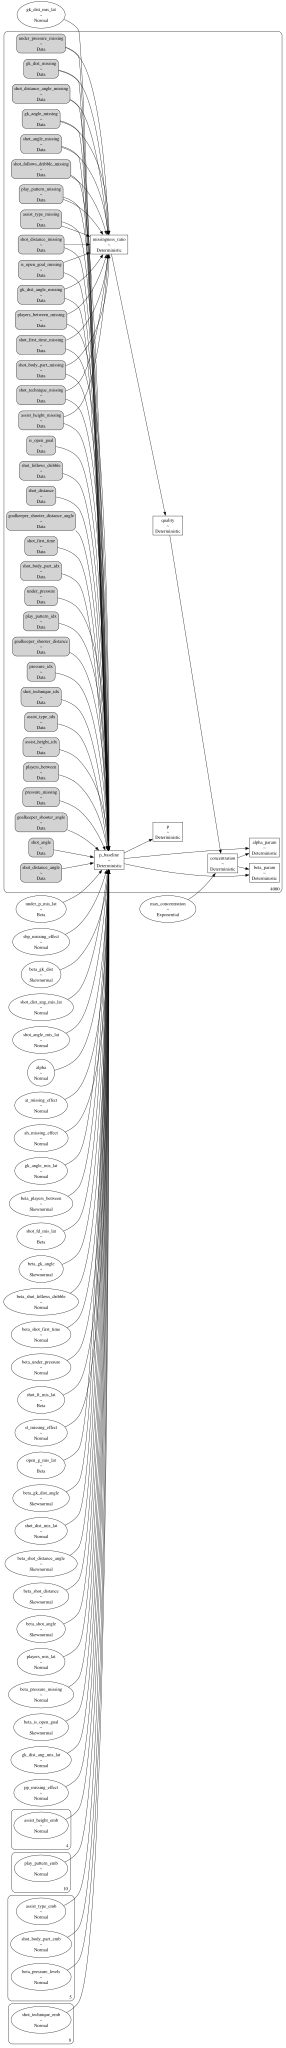

In [ ]:
model_instance = bayesian_xg._build_model()
nodes_to_graph = [v.name for v in model_instance.free_RVs + model_instance.deterministics]

pm.model_to_graphviz(
    model_instance, 
    var_names=nodes_to_graph,
    figsize=(50, 25),
    dpi=100,       
    graph_attr={
        "rankdir": "LR",    
        "size": "10,120!", 
    }
)

### Validation of Sampler --> MCMC method 
- Trace Plots 
- Check R_hats 
- ESS --> effective sample sizes 
- MCSE (small) relative to MCSE (standard deviation)
- Zero Divergences 
- Energy and Forest Plots (on Priors)

#### Trace Plots
1. Beta Priors
2. Embedded 
3. Latent Variables

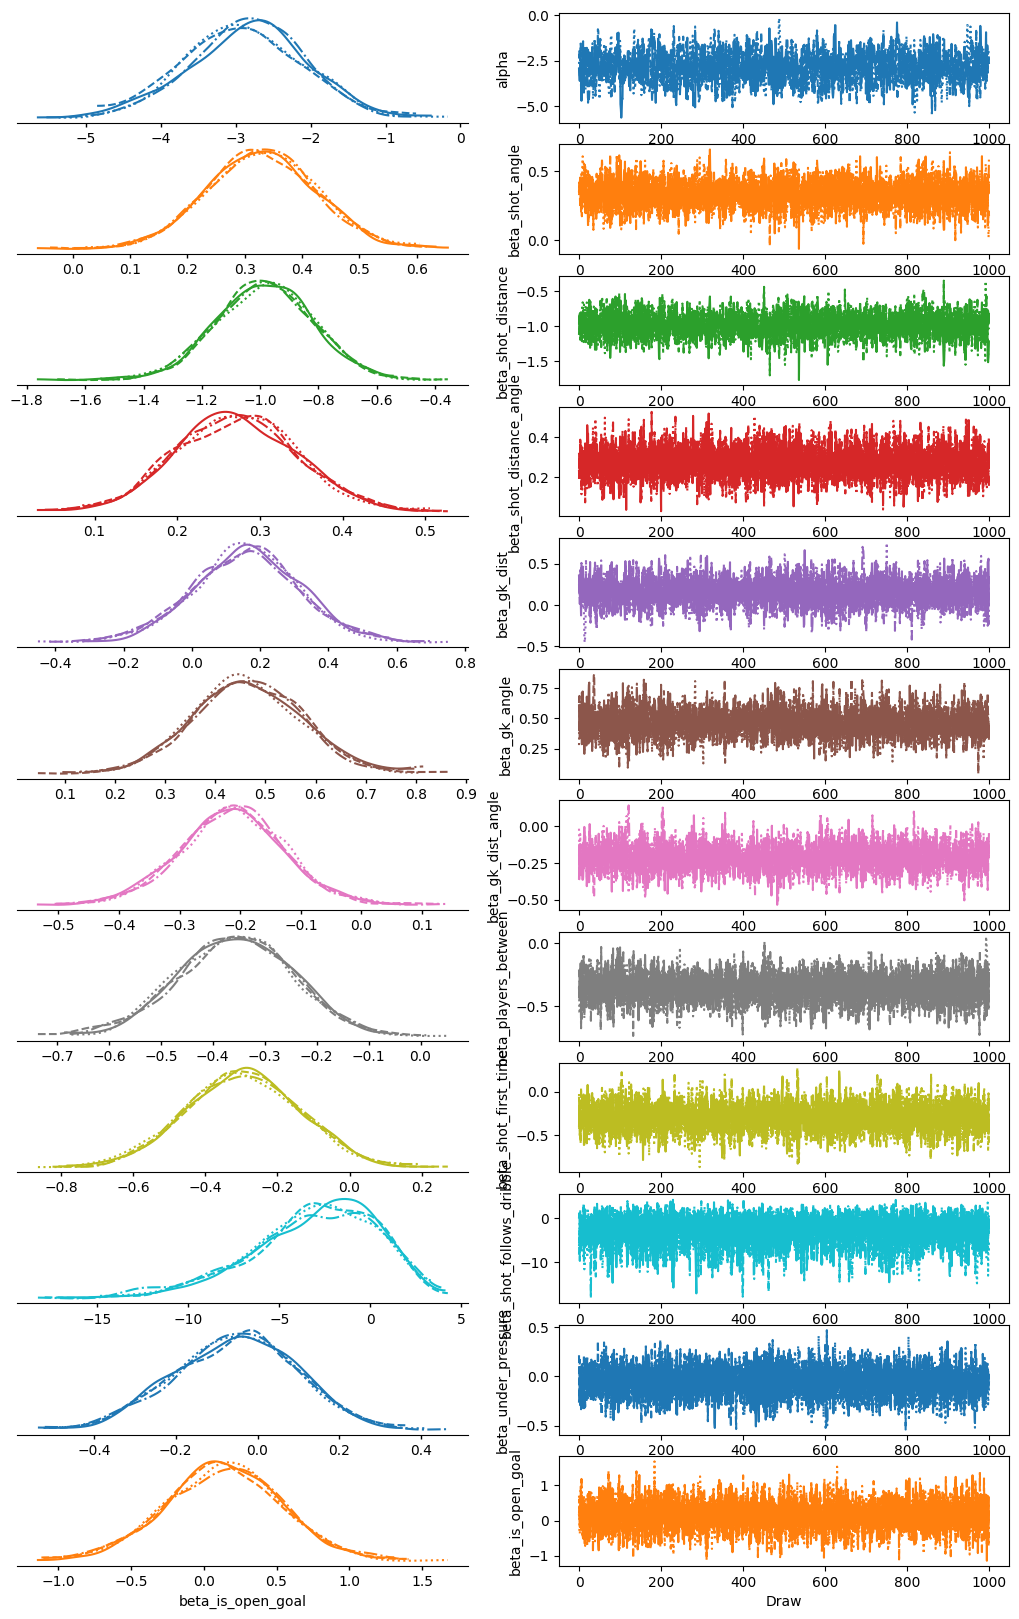

In [373]:
idata = bayesian_xg.idata
var_names = [
  'alpha',
  'beta_shot_angle',
  'beta_shot_distance',
  'beta_shot_distance_angle',
  'beta_gk_dist',
  'beta_gk_angle',
  'beta_gk_dist_angle',
  'beta_players_between',
  'beta_shot_first_time',
  'beta_shot_follows_dribble',
  'beta_under_pressure',
  'beta_is_open_goal'
]

# Selects only variables that explicitly start with "beta_" or "b_"
az.plot_trace_dist(
    idata, 
    var_names=var_names
)

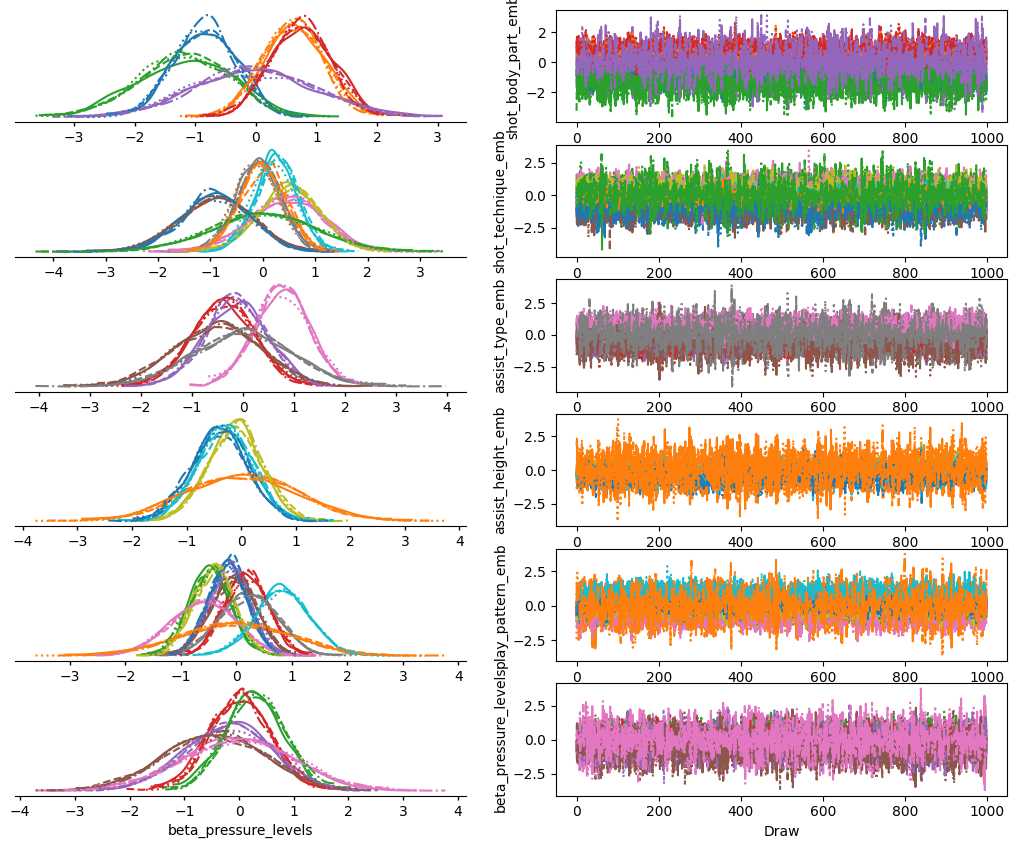

In [ ]:
var_names = [
  'shot_body_part_emb',
  'shot_technique_emb',
  'assist_type_emb',
  'assist_height_emb',
  'play_pattern_emb',
  'beta_pressure_levels',
]

# Selects only variables that explicitly start with "beta_" or "b_"
az.plot_trace_dist(
    idata, 
    var_names=var_names
)

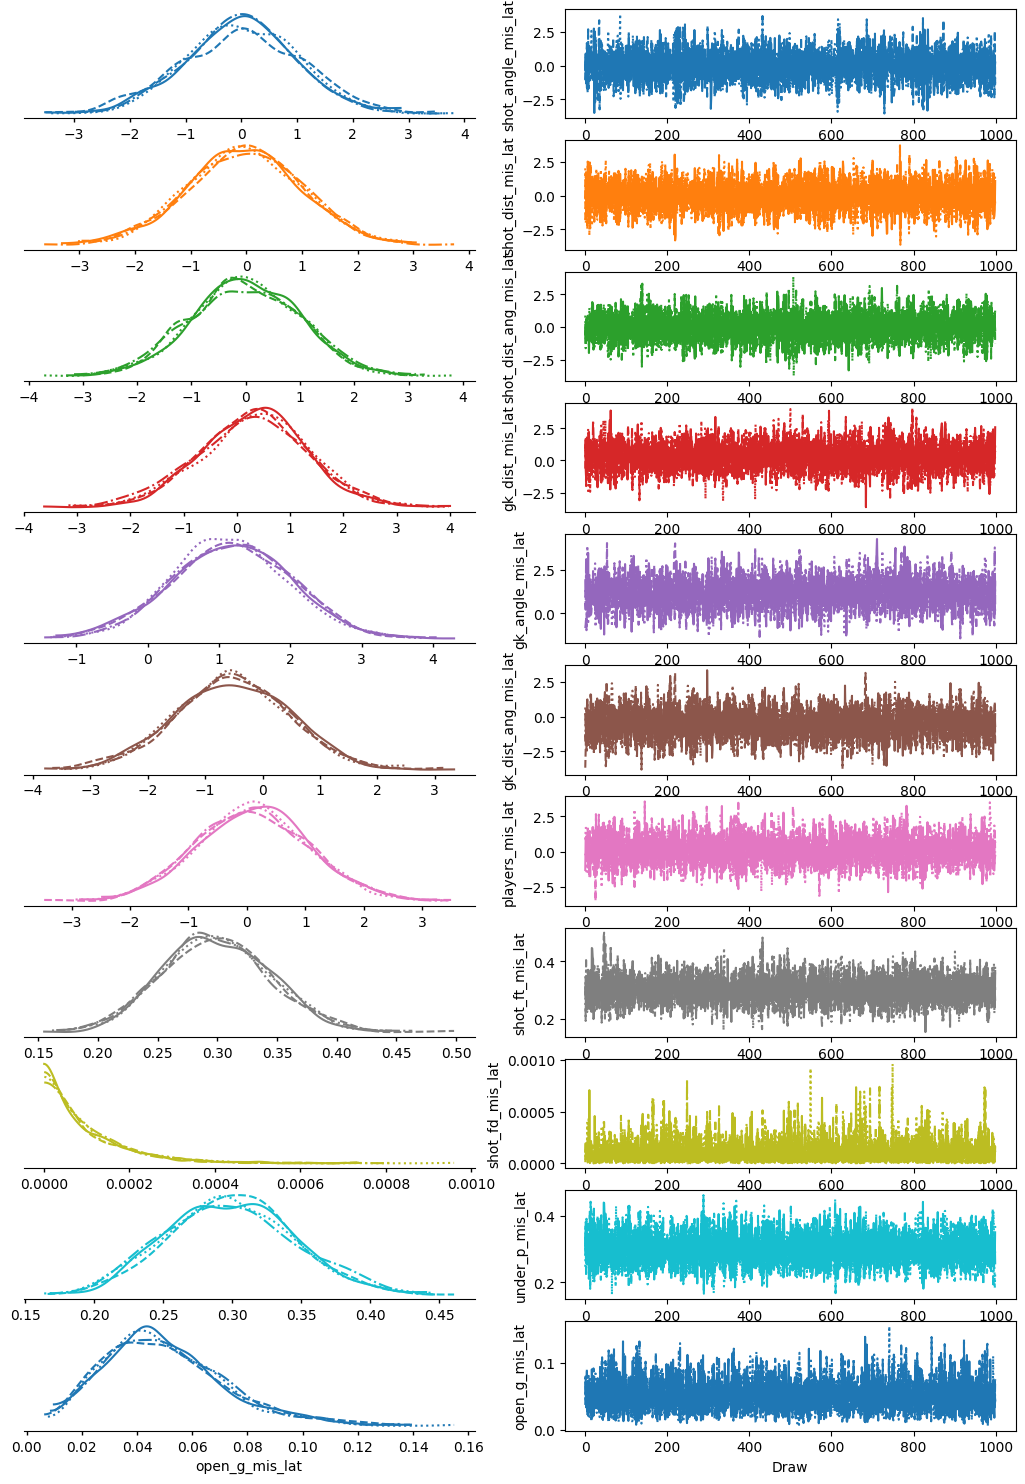

In [377]:
var_names = [
  'shot_angle_mis_lat',
  'shot_dist_mis_lat',
  'shot_dist_ang_mis_lat',
  'gk_dist_mis_lat',
  'gk_angle_mis_lat',
  'gk_dist_ang_mis_lat',
  'players_mis_lat',
  'shot_ft_mis_lat',
  'shot_fd_mis_lat',
  'under_p_mis_lat',
  'open_g_mis_lat',
]

# Selects only variables that explicitly start with "beta_" or "b_"
az.plot_trace_dist(
    idata, 
    var_names=var_names
)

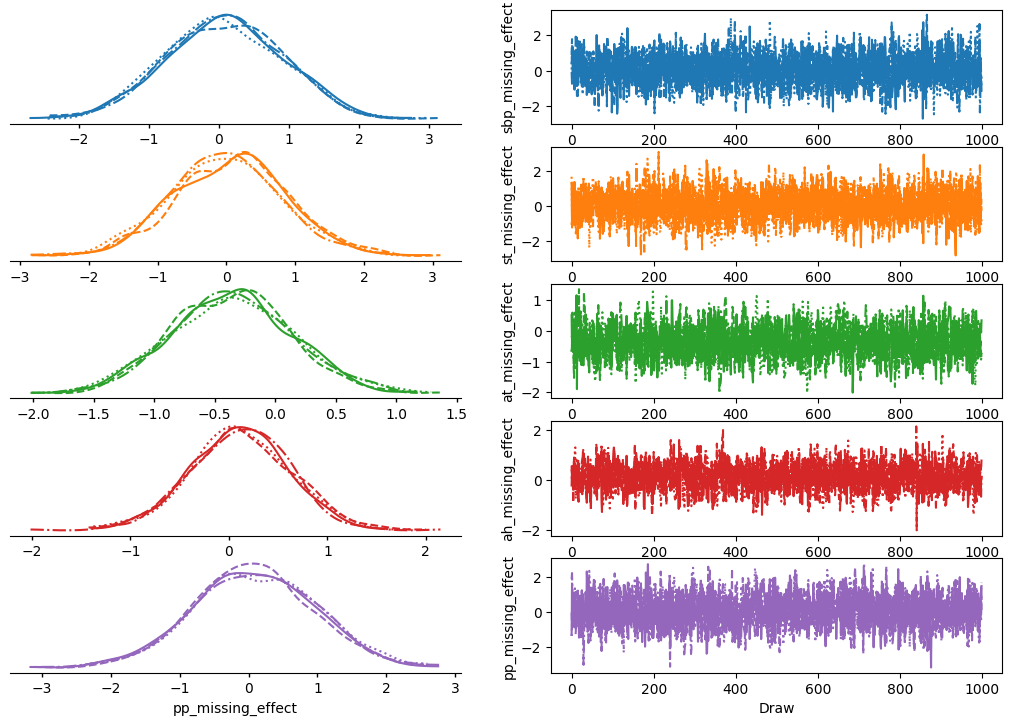

In [378]:
var_names = [
  'sbp_missing_effect',
  'st_missing_effect',
  'at_missing_effect',
  'ah_missing_effect',
  'pp_missing_effect',
]

az.plot_trace_dist(
    idata, 
    var_names=var_names
)

### Check R hats ESS etc..

r_hat --> seems to be around 1.00 of all parameters 
ess --> between 3000-4000 so well sampled good overall mixing between and within chains, 
good mcse_mean relative to mcse_sd --> meaning that the standard errror good

Overall space is well explored. 

In [379]:
summary = pm.summary(idata) 


/var/folders/k4/1yywxhx51772qf1hj2k0zrqh0000gn/T/ipykernel_20948/1992519443.py:1: DeprecationWarning: `pymc.summary` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.summary` instead.
  summary = pm.summary(idata)
/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


In [380]:
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-2.87,0.78,-4.1,-1.6,1103,1470,1.00,0.024,0.017
beta_shot_angle,0.33,0.095,0.18,0.48,3417,3031,1.00,0.0016,0.0012
beta_shot_distance,-0.985,0.165,-1.2,-0.72,2876,2592,1.00,0.0031,0.0023
beta_shot_distance_angle,0.272,0.074,0.16,0.39,4476,3340,1.00,0.0011,0.00078
beta_gk_dist,0.16,0.157,-0.094,0.41,2975,2871,1.00,0.0029,0.0021
...,...,...,...,...,...,...,...,...,...
p[3995],0.0348,0.0079,0.023,0.049,4139,3840,1.00,0.00012,9.9e-05
p[3996],0.0299,0.0101,0.016,0.047,4745,3544,1.00,0.00015,0.00014
p[3997],0.272,0.06,0.18,0.38,4664,3604,1.00,0.00088,0.00061
p[3998],0.093,0.0164,0.068,0.12,5088,3956,1.00,0.00023,0.00018


### Energy Plots

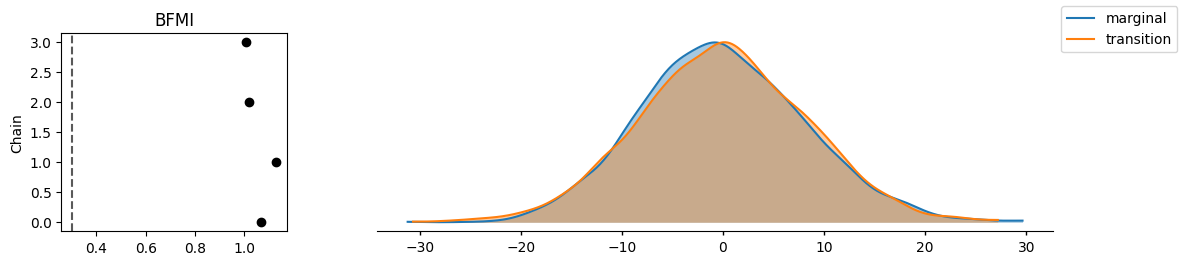

In [381]:
az.plot_energy(idata)

### Forest Plots

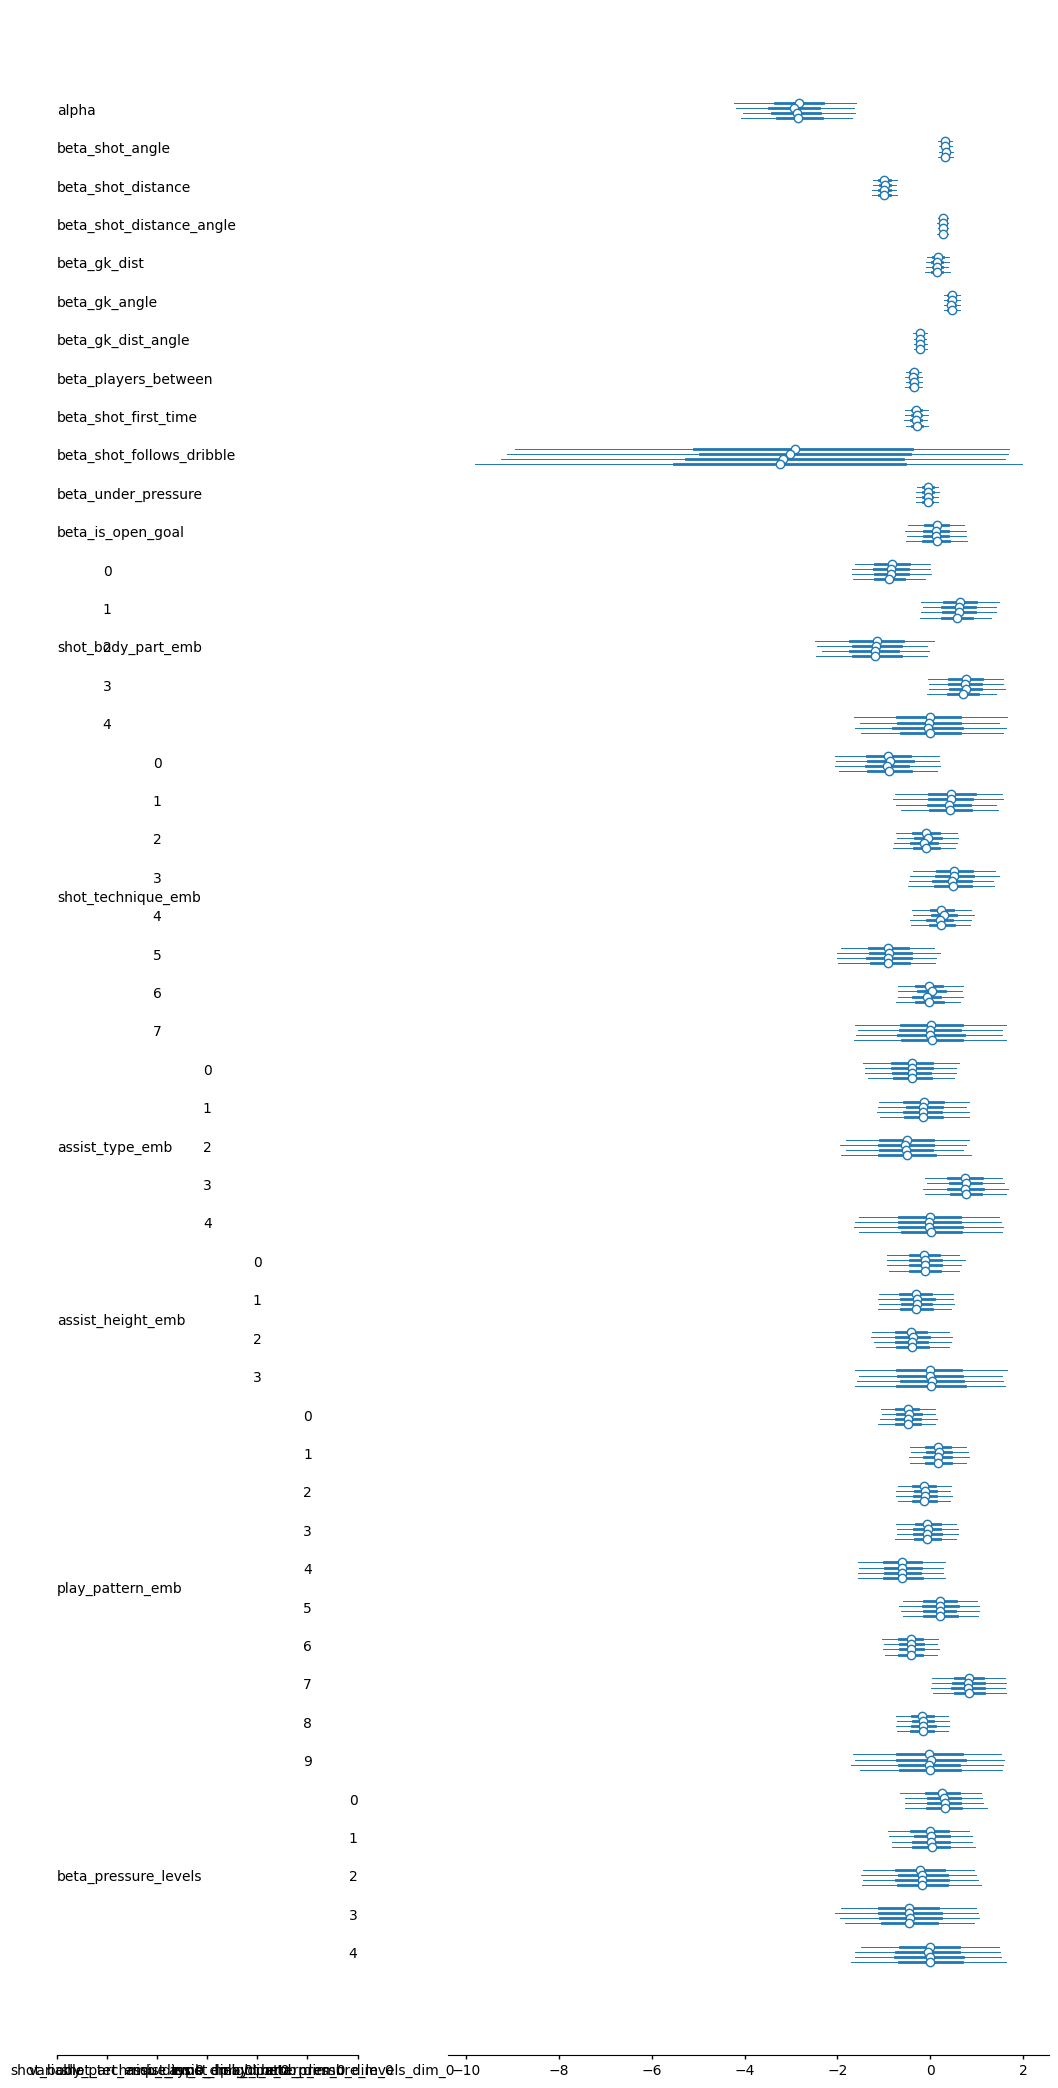

In [384]:
idata = bayesian_xg.idata
var_names = [
  'alpha',
  'beta_shot_angle',
  'beta_shot_distance',
  'beta_shot_distance_angle',
  'beta_gk_dist',
  'beta_gk_angle',
  'beta_gk_dist_angle',
  'beta_players_between',
  'beta_shot_first_time',
  'beta_shot_follows_dribble',
  'beta_under_pressure',
  'beta_is_open_goal',
  'shot_body_part_emb',
  'shot_technique_emb',
  'assist_type_emb',
  'assist_height_emb',
  'play_pattern_emb',
  'beta_pressure_levels',
]

# Selects only variables that explicitly start with "beta_" or "b_"
az.plot_forest(
    idata, 
    var_names=var_names
)

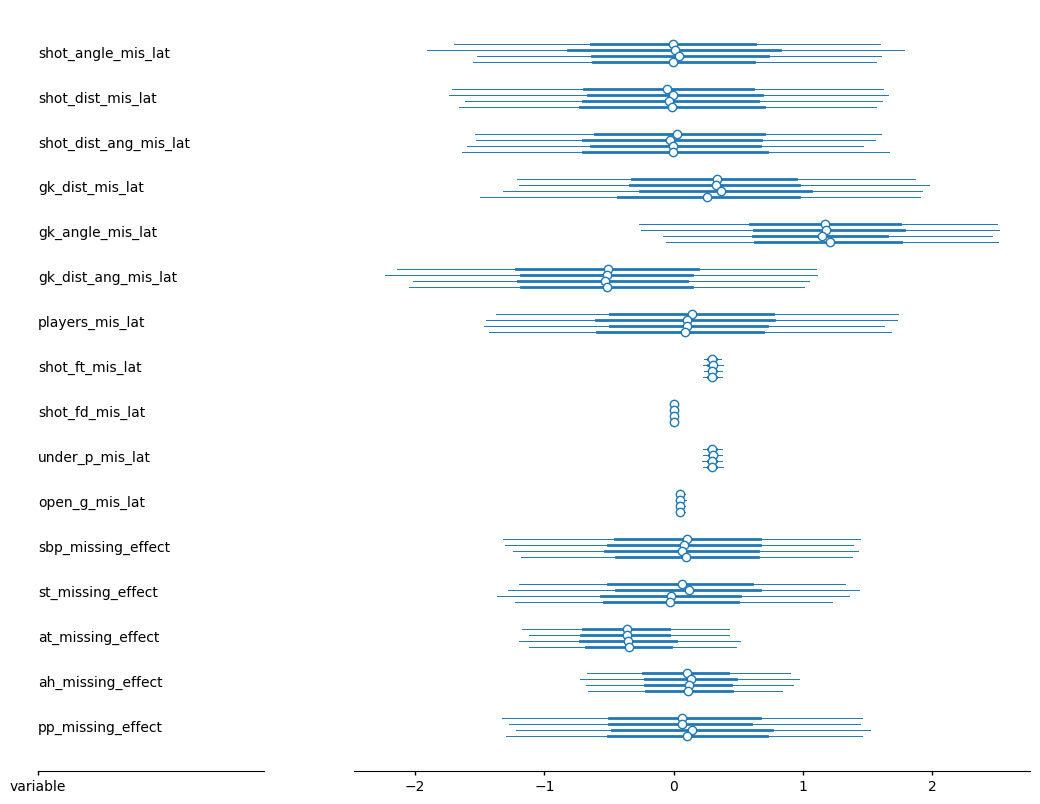

In [385]:
var_names = [
  'shot_angle_mis_lat',
  'shot_dist_mis_lat',
  'shot_dist_ang_mis_lat',
  'gk_dist_mis_lat',
  'gk_angle_mis_lat',
  'gk_dist_ang_mis_lat',
  'players_mis_lat',
  'shot_ft_mis_lat',
  'shot_fd_mis_lat',
  'under_p_mis_lat',
  'open_g_mis_lat',
  'sbp_missing_effect',
  'st_missing_effect',
  'at_missing_effect',
  'ah_missing_effect',
  'pp_missing_effect',
]

# Selects only variables that explicitly start with "beta_" or "b_"
az.plot_forest(
    idata, 
    var_names=var_names
)

### Autocorrelation Plot

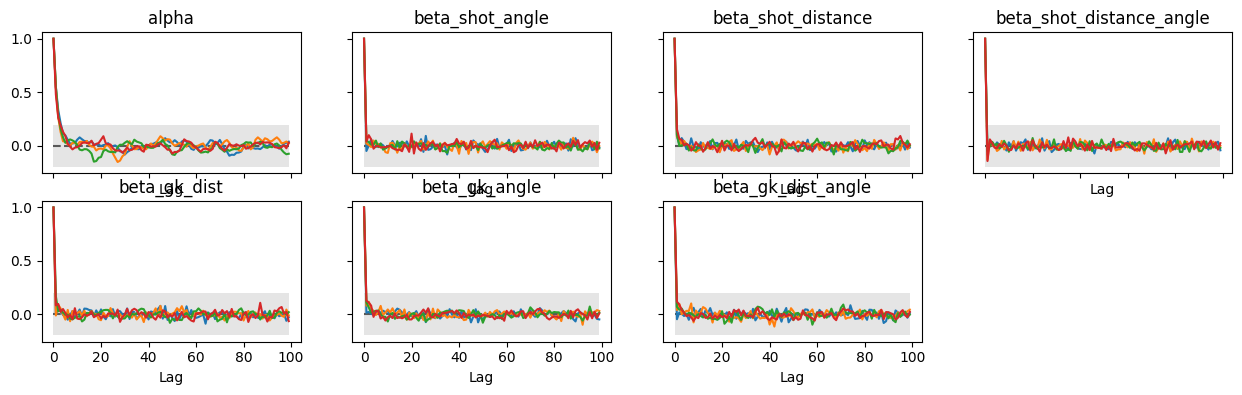

In [389]:
var_names = [
  'alpha',
  'beta_shot_angle',
  'beta_shot_distance',
  'beta_shot_distance_angle',
  'beta_gk_dist',
  'beta_gk_angle',
  'beta_gk_dist_angle',
]


az.plot_autocorr(idata, var_names = var_names)

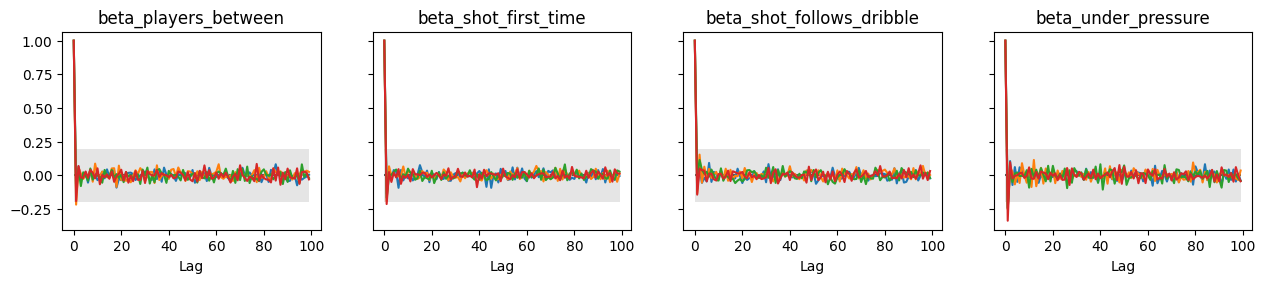

In [391]:
var_names = [
  'beta_players_between',
  'beta_shot_first_time',
  'beta_shot_follows_dribble',
  'beta_under_pressure',
]

az.plot_autocorr(idata, var_names = var_names)

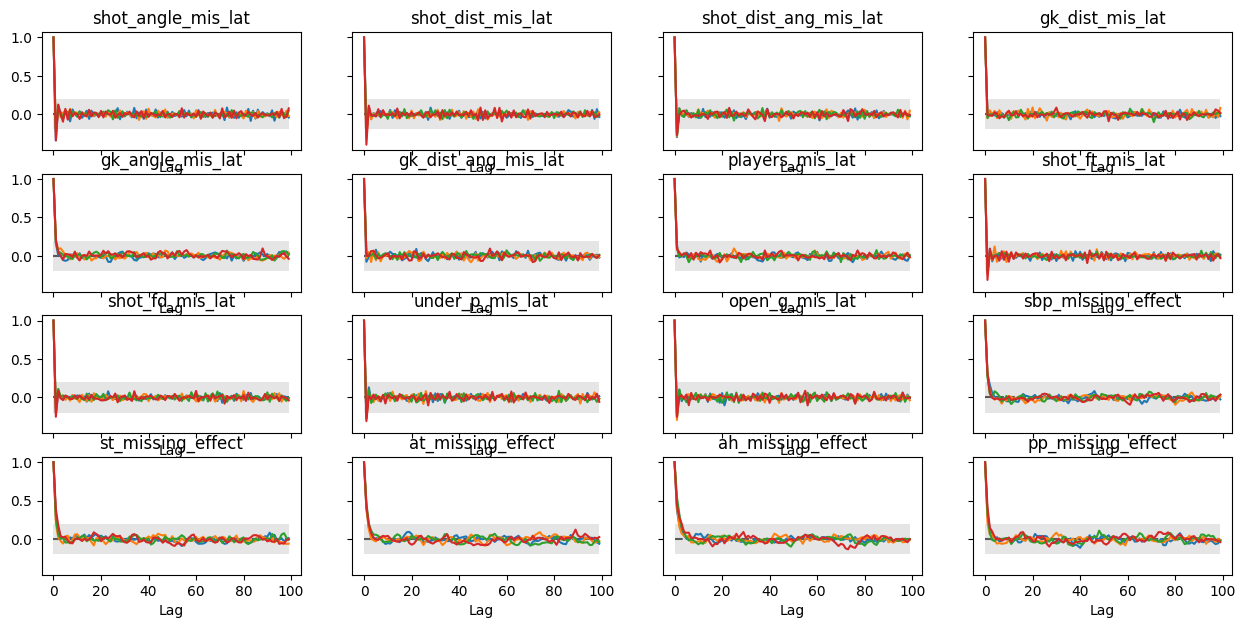

In [ ]:
var_names = [
  'shot_angle_mis_lat',
  'shot_dist_mis_lat',
  'shot_dist_ang_mis_lat',
  'gk_dist_mis_lat',
  'gk_angle_mis_lat',
  'gk_dist_ang_mis_lat',
  'players_mis_lat',
  'shot_ft_mis_lat',
  'shot_fd_mis_lat',
  'under_p_mis_lat',
  'open_g_mis_lat',
  'sbp_missing_effect',
  'st_missing_effect',
  'at_missing_effect',
  'ah_missing_effect',
  'pp_missing_effect',
]


az.plot_autocorr(idata, var_names = var_names)

### Validate Posterior

In [418]:
with bayesian_xg._build_model() as model:
    vals = pm.sample_posterior_predictive(idata, var_names=["y_obs", "p", "alpha_param", "beta_param"], random_seed=42)

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

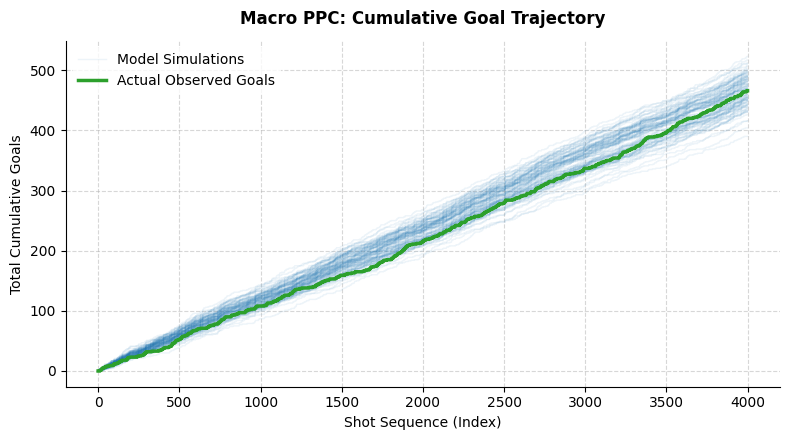

In [ ]:
y_true = vals.observed_data["y_obs"].values
y_sims = vals.posterior_predictive["y_obs"].values
y_sims_flat = y_sims.reshape(-1, y_sims.shape[-1])
true_cumsum = np.cumsum(y_true)
sim_cumsums = np.cumsum(y_sims_flat, axis=1)
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)

np.random.seed(42)
sample_indices = np.random.choice(sim_cumsums.shape[0], size=100, replace=False)

for idx in sample_indices:
    ax.plot(sim_cumsums[idx], color="#1f77b4", alpha=0.08, linewidth=1, label="Model Simulations" if idx == sample_indices[0] else "")

ax.plot(true_cumsum, color="#2ca02c", linewidth=2.5, label="Actual Observed Goals")

ax.set_title("Macro PPC: Cumulative Goal Trajectory", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Shot Sequence (Index)", fontsize=10)
ax.set_ylabel("Total Cumulative Goals", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Log-Likelihood

In [439]:
# Modifies the idata object in-place to inject the 'log_likelihood' group
pm.compute_log_likelihood(idata, model=bayesian_xg._build_model())

Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                     (chain: 4, draw: 1000,
│                                        shot_body_part_emb_dim_0: 5,
│                                        shot_technique_emb_dim_0: 8,
│                                        assist_type_emb_dim_0: 5,
│                                        assist_height_emb_dim_0: 4,
│                                        play_pattern_emb_dim_0: 10,
│                                        ...
│                                        p_baseline_dim_0: 4000,
│                                        missingness_ratio_dim_0: 4000,
│                                        quality_dim_0: 4000,
│                                        concentration_dim_0: 4000,
│                                        alpha_param_dim_0: 4000,
│                                        beta_param_dim_0: 4000, p_dim_0: 4000)
│       Coordinates: (12/15)
│         * chain                       (chain) int64 32B 0 1 2 3
│         * draw                        (draw) int64 8kB 0 1 2 3 4 ... 996 997 998 999
│         * shot_body_part_emb_dim_0    (shot_body_part_emb_dim_0) int64 40B 0 1 2 3 4
│         * shot_technique_emb_dim_0    (shot_technique_emb_dim_0) int64 64B 0 1 ... 6 7
│         * assist_type_emb_dim_0       (assist_type_emb_dim_0) int64 40B 0 1 2 3 4
│         * assist_height_emb_dim_0     (assist_height_emb_dim_0) int64 32B 0 1 2 3
│           ...                          ...
│         * missingness_ratio_dim_0     (missingness_ratio_dim_0) int64 32kB 0 ... 3999
│         * quality_dim_0               (quality_dim_0) int64 32kB 0 1 2 ... 3998 3999
│         * concentration_dim_0         (concentration_dim_0) int64 32kB 0 1 ... 3999
│         * alpha_param_dim_0           (alpha_param_dim_0) int64 32kB 0 1 ... 3998 3999
│         * beta_param_dim_0            (beta_param_dim_0) int64 32kB 0 1 ... 3998 3999
│         * p_dim_0                     (p_dim_0) int64 32kB 0 1 2 3 ... 3997 3998 3999
│       Data variables: (12/43)
│           alpha                       (chain, draw) float64 32kB -2.95 ... -2.485
│           beta_shot_angle             (chain, draw) float64 32kB 0.3569 ... 0.5813
│           beta_shot_distance          (chain, draw) float64 32kB -1.11 ... -0.7721
│           beta_shot_distance_angle    (chain, draw) float64 32kB 0.2314 ... 0.1579
│           beta_gk_dist                (chain, draw) float64 32kB 0.3564 ... 0.3518
│           beta_gk_angle               (chain, draw) float64 32kB 0.6073 ... 0.4459
│           ...                          ...
│           missingness_ratio           (chain, draw, missingness_ratio_dim_0) float64 128MB ...
│           quality                     (chain, draw, quality_dim_0) float64 128MB 0....
│           concentration               (chain, draw, concentration_dim_0) float64 128MB ...
│           alpha_param                 (chain, draw, alpha_param_dim_0) float64 128MB ...
│           beta_param                  (chain, draw, beta_param_dim_0) float64 128MB ...
│           p                           (chain, draw, p_dim_0) float64 128MB 0.01032 ...
│       Attributes:
│           created_at:                 2026-06-06T22:40:24.460772+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 6 6 5 5 5 ... 6 5 6 5 5
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 0.1812 ... 0.1609
│          

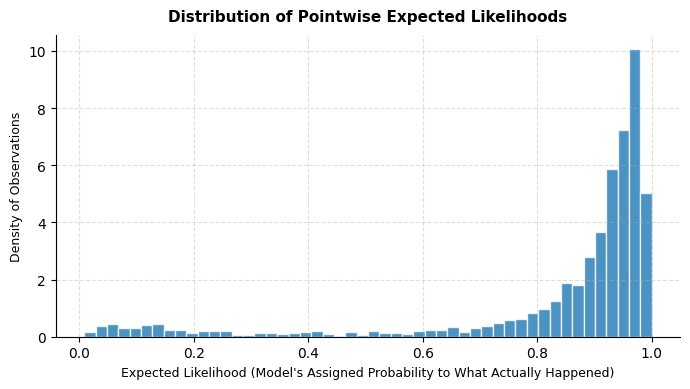

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

log_like = idata.log_likelihood["y_obs"].values
like = np.exp(log_like)
mean_pointwise_likelihood = np.mean(like, axis=(0, 1))
fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

ax.hist(
    mean_pointwise_likelihood, 
    bins=50, 
    color="#1f77b4", 
    edgecolor="white", 
    alpha=0.8,
    density=True
)

# Formatting
ax.set_title("Distribution of Pointwise Expected Likelihoods", fontsize=11, fontweight="bold", pad=10)
ax.set_xlabel("Expected Likelihood (Model's Assigned Probability to What Actually Happened)", fontsize=9)
ax.set_ylabel("Density of Observations", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [444]:
az.loo(idata, pointwise=True)

Computed from 4000 posterior samples and 4000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1167.72    40.51
p_loo       35.38        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     4000  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

### Generating Posterior Predictive Samples for all Data Sets
- Sampling posterior predictive 
- Generating latest probability of goal values 
    - Doing this as for some reason splitting up the Beta and the Binomial Distribution didn't work 
    - This generates the xg_mean and xg_std from the alpha_param, beta_param, as they take into account the missingness of the data
        as highlighted in the graphical representation of the model above. 

In [ ]:
pps_full = bayesian_xg._posterior_predict_sampling(df_test_full, target_col="is_goal", n_samples=1000)
pps_xy = bayesian_xg._posterior_predict_sampling(df_test_xy_only, target_col="is_goal", n_samples=1000)
pps_secondary = bayesian_xg._posterior_predict_sampling(df_test_secondary, target_col="is_goal", n_samples=1000)

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

In [476]:
def extract_latent_p_stats(pps_dataset):
    """
    Extracts the analytical alpha and beta parameters from posterior predictive,
    generates the uncollapsed p_latent space, and returns the mean and std.
    """
    # Extract coordinates: Shape will be (chains, draws, n_records)
    alphas = pps_dataset["predictions"]["alpha_param"].values
    betas = pps_dataset["predictions"]["beta_param"].values
    p_latent_draws = np.random.beta(alphas, betas)
    mean_slice = p_latent_draws.mean(axis=(0, 1))
    std_slice = p_latent_draws.std(axis=(0, 1))
    
    return mean_slice, std_slice

### Full Data Log-Loss Curve

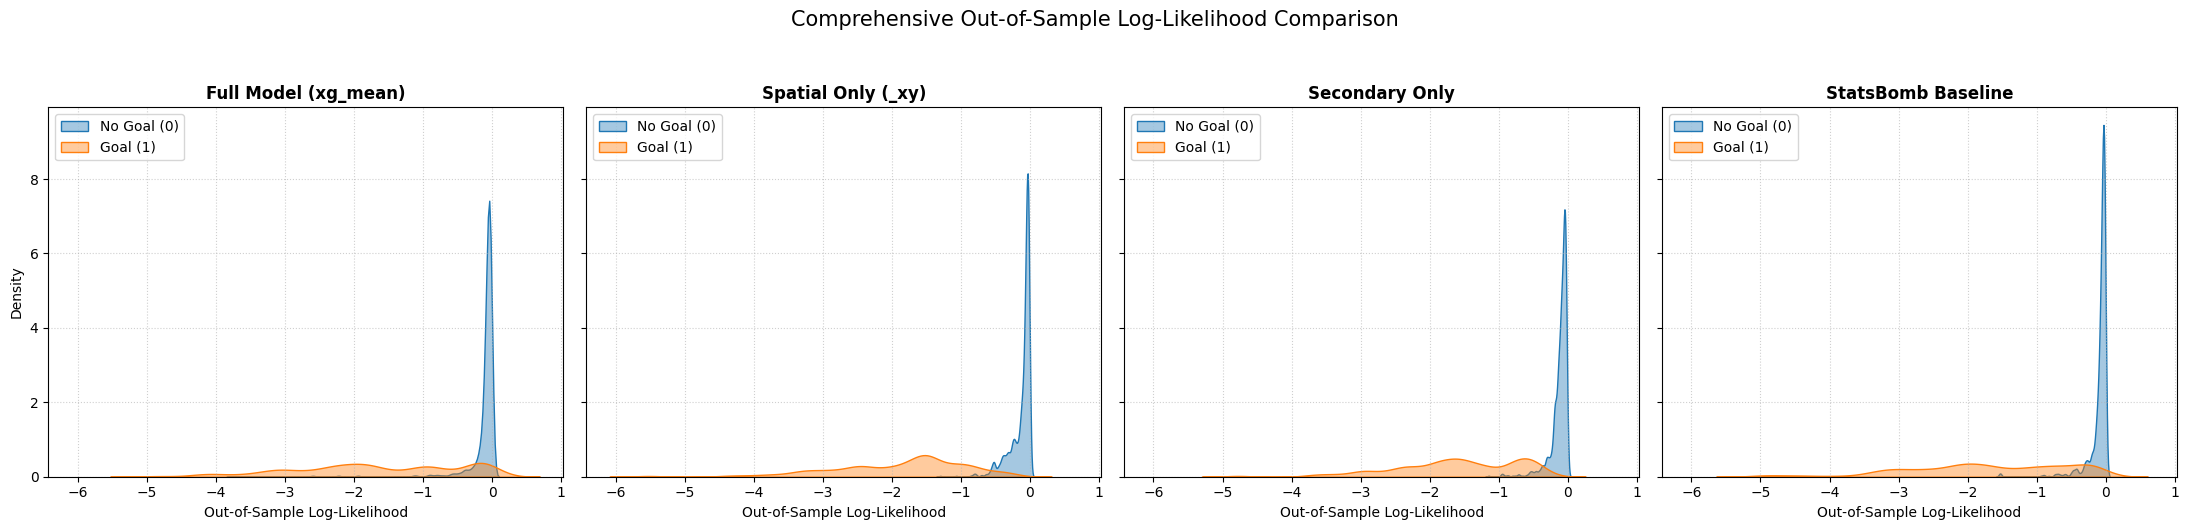

In [483]:

# 1. Setup Data & Containers
y_true = df_test["is_goal"].values
eps = 1e-15

# Dictionary to dynamically hold mean predicted probabilities for each variant
models_probs = {
    "Full Model (xg_mean)": pps_full["predictions"]["p"].values.mean(axis=(0, 1)),
    "Spatial Only (_xy)": pps_xy["predictions"]["p"].values.mean(axis=(0, 1)),
    "Secondary Only": pps_secondary["predictions"]["p"].values.mean(axis=(0, 1)),
    "StatsBomb Baseline": np.asarray(df_test["shot_statsbomb_xg"])
}

# 2. Initialize the Subplots (1 Row, 4 Columns)
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

# 3. Loop through models and plot dynamically
for ax, (model_name, probs) in zip(axes, models_probs.items()):
    # Clip and calculate pointwise log-likelihood
    p_clipped = np.clip(probs, eps, 1 - eps)
    pointwise_ll = y_true * np.log(p_clipped) + (1 - y_true) * np.log(1 - p_clipped)
    
    # Plot No Goal (0)
    sns.kdeplot(
        pointwise_ll[y_true == 0], 
        bw_adjust=0.5, 
        label="No Goal (0)", 
        fill=True, 
        alpha=0.4, 
        color="C0", 
        ax=ax
    )
    
    # Plot Goal (1)
    sns.kdeplot(
        pointwise_ll[y_true == 1], 
        bw_adjust=0.5, 
        label="Goal (1)", 
        fill=True, 
        alpha=0.4, 
        color="C1", 
        ax=ax
    )
    
    # Subplot Formatting
    ax.set_xlabel("Out-of-Sample Log-Likelihood")
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")

# Adjust labels for cleaner presentation
axes[0].set_ylabel("Density")
for ax in axes[1:]:
    ax.set_ylabel("") # Hide redundant y-labels since scales are shared

# 4. Final Polish
plt.suptitle("Comprehensive Out-of-Sample Log-Likelihood Comparison", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

In [485]:
df_test["xg_mean"], df_test["xg_std"] = extract_latent_p_stats(pps_full)
df_test["xg_mean_only_xy"], df_test["xg_std_only_xy"] = extract_latent_p_stats(pps_xy)
df_test["xg_mean_only_secondary"], df_test["xg_std_only_secondary"] = extract_latent_p_stats(pps_secondary)

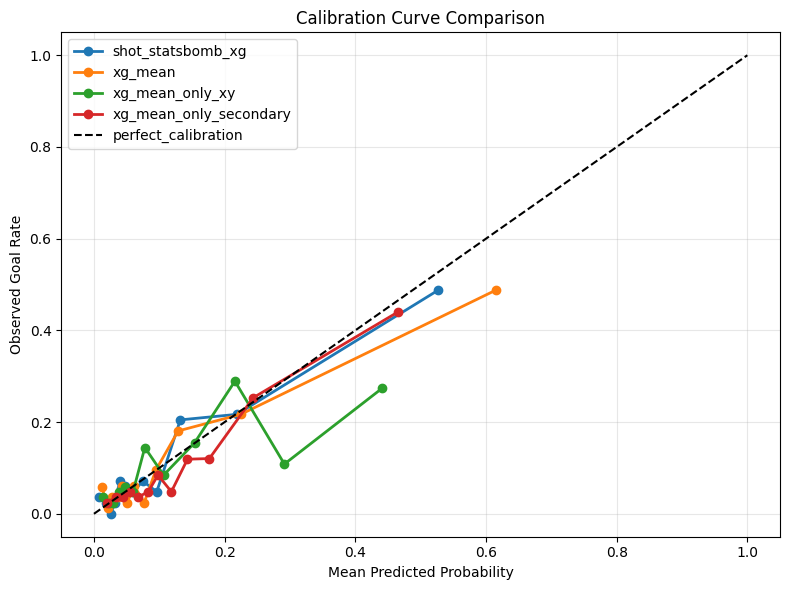

,model,roc_auc,log_loss,brier_score
0,shot_statsbomb_xg,0.802794,0.271565,0.076476
1,xg_mean,0.789591,0.283437,0.079930
2,xg_mean_only_secondary,0.778027,0.286498,0.080636
3,xg_mean_only_xy,0.716731,0.321912,0.093527


In [486]:
required_cols = ["is_goal", "shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]
missing_cols = [c for c in required_cols if c not in df_test.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for calibration/metrics: {missing_cols}")

eval_df = df_test[required_cols].dropna().copy()
eval_df["is_goal"] = eval_df["is_goal"].astype(int)

pred_cols = ["shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]
for c in pred_cols:
    eval_df[c] = np.clip(eval_df[c].astype(float), 1e-6, 1 - 1e-6)

# Calibration plot: all three on same chart
plt.figure(figsize=(8, 6))
for c in pred_cols:
    frac_pos, mean_pred = calibration_curve(eval_df["is_goal"], eval_df[c], n_bins=12, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=c)

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="perfect_calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics table: ROC AUC, log loss, brier score
metrics_rows = []
for c in pred_cols:
    metrics_rows.append({
        "model": c,
        "roc_auc": roc_auc_score(eval_df["is_goal"], eval_df[c]),
        "log_loss": log_loss(eval_df["is_goal"], eval_df[c]),
        "brier_score": brier_score_loss(eval_df["is_goal"], eval_df[c]),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
metrics_df

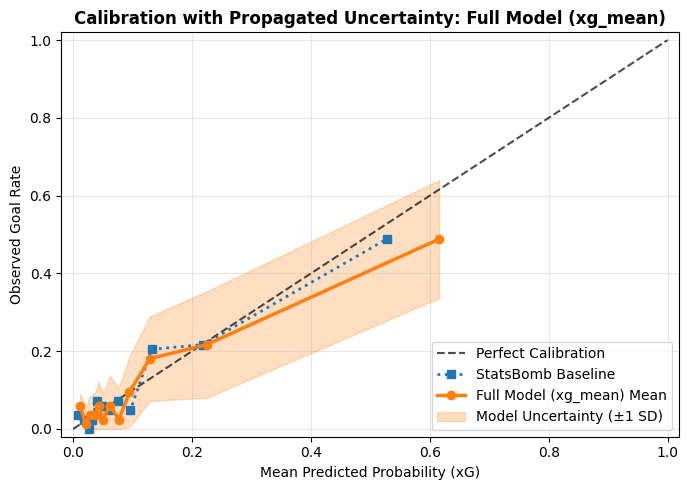

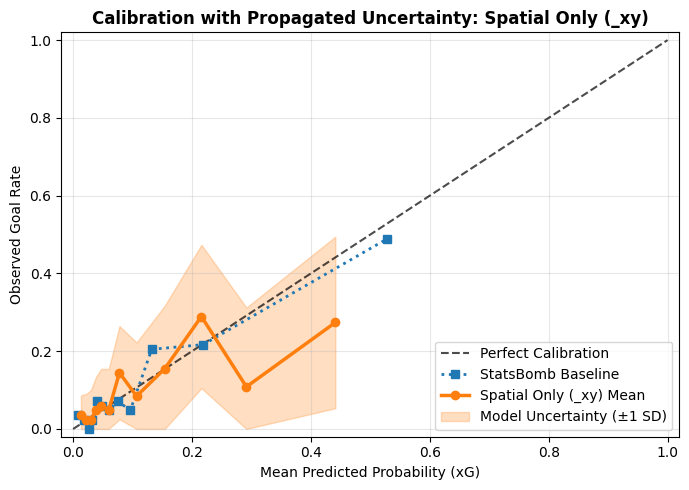

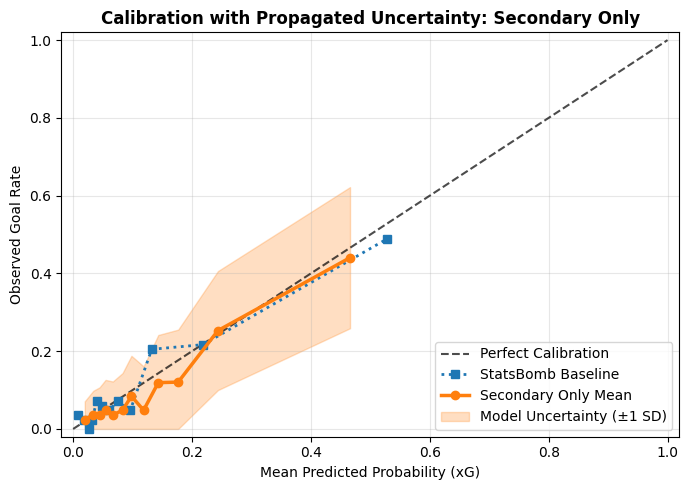

In [494]:
eval_df = df_test.copy()
y_true = eval_df["is_goal"].values
sb_xg = eval_df["shot_statsbomb_xg"].values
n_bins = 12
strategy = "quantile"
eps = 1e-6

model_configurations = {
    "Full Model (xg_mean)": {
        "mean_col": "xg_mean", 
        "std_col": "xg_std"
    },
    "Spatial Only (_xy)": {
        "mean_col": "xg_mean_only_xy", 
        "std_col": "xg_std_only_xy"
    },
    "Secondary Only": {
        "mean_col": "xg_mean_only_secondary", 
        "std_col": "xg_std_only_secondary"
    }
}

for model_name, cols in model_configurations.items():
    means = eval_df[cols["mean_col"]].values
    stds = eval_df[cols["std_col"]].values
    frac_pos, mean_pred = calibration_curve(
        y_true, means, n_bins=n_bins, strategy=strategy
    )

    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.percentile(means, quantiles * 100)
    bin_edges[-1] = 1.05 # Ensure the upper bound catches the max value
    
    binned_stds = []
    for i in range(n_bins):
        in_bin = (means >= bin_edges[i]) & (means < bin_edges[i+1])
        
        if np.sum(in_bin) > 0:
            bin_variance = np.mean(stds[in_bin] ** 2)
            binned_stds.append(np.sqrt(bin_variance))
        else:
            binned_stds.append(0)
            
    binned_stds = np.array(binned_stds)
    lower_bound = np.clip(frac_pos - binned_stds, 0, 1)
    upper_bound = np.clip(frac_pos + binned_stds, 0, 1)
    
    plt.figure(figsize=(7, 5))
    plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration", alpha=0.7)
    
    sb_frac, sb_mean = calibration_curve(y_true, sb_xg, n_bins=n_bins, strategy=strategy)
    plt.plot(sb_mean, sb_frac, color="C0", linestyle=":", linewidth=2, marker="s", label="StatsBomb Baseline")
    plt.plot(mean_pred, frac_pos, color="C1", linewidth=2.5, marker="o", label=f"{model_name} Mean")
    plt.fill_between(
        mean_pred, lower_bound, upper_bound, 
        color="C1", alpha=0.25, label="Model Uncertainty (±1 SD)"
    )
    plt.xlabel("Mean Predicted Probability (xG)")
    plt.ylabel("Observed Goal Rate")
    plt.title(f"Calibration with Propagated Uncertainty: {model_name}", fontsize=12, fontweight="bold")
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Uncertainity Distribution Goal
- Checks to see, the less informed dataset has the widest distribution on average
- Validates that model, was able to effectively create wider posterior distributions for more un-certain features. 

In [445]:
df_test[["shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]]

,shot_statsbomb_xg,xg_mean,xg_mean_only_xy,xg_mean_only_secondary
1501,0.048853,0.081818,0.057634,0.098653
2586,0.120717,0.079815,0.061815,0.128183
2653,0.083350,0.072178,0.079862,0.120683
1055,0.084016,0.129993,0.111556,0.183923
705,0.023258,0.023340,0.026736,0.033038
...,...,...,...,...
4711,0.019543,0.025349,0.016335,0.028439
2313,0.371584,0.156283,0.148617,0.258718
3214,0.009147,0.026278,0.017598,0.026806
2732,0.040308,0.043743,0.076050,0.083605


In [446]:
df_test[["xg_std", "xg_std_only_xy", "xg_std_only_secondary"]]

,xg_std,xg_std_only_xy,xg_std_only_secondary
1501,0.080480,0.106782,0.102666
2586,0.081977,0.102719,0.115379
2653,0.077799,0.120620,0.114863
1055,0.102900,0.141323,0.135735
705,0.047426,0.073195,0.066100
...,...,...,...
4711,0.046307,0.056260,0.058685
2313,0.116691,0.159695,0.148843
3214,0.051335,0.056921,0.052738
2732,0.060076,0.118542,0.096874


In [337]:
print(df_test["xg_std"].mean())
print(df_test["xg_std_only_xy"].mean())
print(df_test["xg_std_only_secondary"].mean())

0.07754013781667433
0.1253741426580481
0.10288365351816207
